# Análisis de datos - TP Final

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import kagglehub
from scipy import stats as st
from scipy.stats import describe

In [6]:
pd.options.display.float_format = '{:,.4f}'.format

## Exploración y comprensión de los datos

### Cargar el dataset proporcionado y realizar un análisis exploratorio de los datos.

In [7]:
# Download latest version
path = kagglehub.dataset_download("asaniczka/tmdb-movies-dataset-2023-930k-movies")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\Valentin\.cache\kagglehub\datasets\asaniczka\tmdb-movies-dataset-2023-930k-movies\versions\911


In [8]:
df = pd.read_csv(path + "/TMDB_movie_dataset_v11.csv", na_values='sin especificar', encoding='ISO-8859-1')
df.head()

,id,title,vote_average,vote_count,status,release_date,revenue,runtime,adult,backdrop_path,...,original_title,overview,popularity,poster_path,tagline,genres,production_companies,production_countries,spoken_languages,keywords
0,27205,Inception,8.3640,34495,Released,2010-07-15,825532764,148,False,/8ZTVqvKDQ8emSGUEMjsS4yHAwrp.jpg,...,Inception,"Cobb, a skilled thief who commits corporate es...",83.9520,/oYuLEt3zVCKq57qu2F8dT7NIa6f.jpg,Your mind is the scene of the crime.,"Action, Science Fiction, Adventure","Legendary Pictures, Syncopy, Warner Bros. Pict...","United Kingdom, United States of America","English, French, Japanese, Swahili","rescue, mission, dream, airplane, paris, franc..."
1,157336,Interstellar,8.4170,32571,Released,2014-11-05,701729206,169,False,/pbrkL804c8yAv3zBZR4QPEafpAR.jpg,...,Interstellar,The adventures of a group of explorers who mak...,140.2410,/gEU2QniE6E77NI6lCU6MxlNBvIx.jpg,Mankind was born on Earth. It was never meant ...,"Adventure, Drama, Science Fiction","Legendary Pictures, Syncopy, Lynda Obst Produc...","United Kingdom, United States of America",English,"rescue, future, spacecraft, race against time,..."
2,155,The Dark Knight,8.5120,30619,Released,2008-07-16,1004558444,152,False,/nMKdUUepR0i5zn0y1T4CsSB5chy.jpg,...,The Dark Knight,Batman raises the stakes in his war on crime. ...,130.6430,/qJ2tW6WMUDux911r6m7haRef0WH.jpg,Welcome to a world without rules.,"Drama, Action, Crime, Thriller","DC Comics, Legendary Pictures, Syncopy, Isobel...","United Kingdom, United States of America","English, Mandarin","joker, sadism, chaos, secret identity, crime f..."
3,19995,Avatar,7.5730,29815,Released,2009-12-15,2923706026,162,False,/vL5LR6WdxWPjLPFRLe133jXWsh5.jpg,...,Avatar,"In the 22nd century, a paraplegic Marine is di...",79.9320,/kyeqWdyUXW608qlYkRqosgbbJyK.jpg,Enter the world of Pandora.,"Action, Adventure, Fantasy, Science Fiction","Dune Entertainment, Lightstorm Entertainment, ...","United States of America, United Kingdom","English, Spanish","future, society, culture clash, space travel, ..."
4,24428,The Avengers,7.7100,29166,Released,2012-04-25,1518815515,143,False,/9BBTo63ANSmhC4e6r62OJFuK2GL.jpg,...,The Avengers,When an unexpected enemy emerges and threatens...,98.0820,/RYMX2wcKCBAr24UyPD7xwmjaTn.jpg,Some assembly required.,"Science Fiction, Action, Adventure",Marvel Studios,United States of America,"English, Hindi, Russian","new york city, superhero, shield, based on com..."


In [9]:
df.shape

(1407834, 24)

In [10]:
df.columns

Index(['id', 'title', 'vote_average', 'vote_count', 'status', 'release_date',
       'revenue', 'runtime', 'adult', 'backdrop_path', 'budget', 'homepage',
       'imdb_id', 'original_language', 'original_title', 'overview',
       'popularity', 'poster_path', 'tagline', 'genres',
       'production_companies', 'production_countries', 'spoken_languages',
       'keywords'],
      dtype='str')

In [11]:
df.head(5)

,id,title,vote_average,vote_count,status,release_date,revenue,runtime,adult,backdrop_path,...,original_title,overview,popularity,poster_path,tagline,genres,production_companies,production_countries,spoken_languages,keywords
0,27205,Inception,8.3640,34495,Released,2010-07-15,825532764,148,False,/8ZTVqvKDQ8emSGUEMjsS4yHAwrp.jpg,...,Inception,"Cobb, a skilled thief who commits corporate es...",83.9520,/oYuLEt3zVCKq57qu2F8dT7NIa6f.jpg,Your mind is the scene of the crime.,"Action, Science Fiction, Adventure","Legendary Pictures, Syncopy, Warner Bros. Pict...","United Kingdom, United States of America","English, French, Japanese, Swahili","rescue, mission, dream, airplane, paris, franc..."
1,157336,Interstellar,8.4170,32571,Released,2014-11-05,701729206,169,False,/pbrkL804c8yAv3zBZR4QPEafpAR.jpg,...,Interstellar,The adventures of a group of explorers who mak...,140.2410,/gEU2QniE6E77NI6lCU6MxlNBvIx.jpg,Mankind was born on Earth. It was never meant ...,"Adventure, Drama, Science Fiction","Legendary Pictures, Syncopy, Lynda Obst Produc...","United Kingdom, United States of America",English,"rescue, future, spacecraft, race against time,..."
2,155,The Dark Knight,8.5120,30619,Released,2008-07-16,1004558444,152,False,/nMKdUUepR0i5zn0y1T4CsSB5chy.jpg,...,The Dark Knight,Batman raises the stakes in his war on crime. ...,130.6430,/qJ2tW6WMUDux911r6m7haRef0WH.jpg,Welcome to a world without rules.,"Drama, Action, Crime, Thriller","DC Comics, Legendary Pictures, Syncopy, Isobel...","United Kingdom, United States of America","English, Mandarin","joker, sadism, chaos, secret identity, crime f..."
3,19995,Avatar,7.5730,29815,Released,2009-12-15,2923706026,162,False,/vL5LR6WdxWPjLPFRLe133jXWsh5.jpg,...,Avatar,"In the 22nd century, a paraplegic Marine is di...",79.9320,/kyeqWdyUXW608qlYkRqosgbbJyK.jpg,Enter the world of Pandora.,"Action, Adventure, Fantasy, Science Fiction","Dune Entertainment, Lightstorm Entertainment, ...","United States of America, United Kingdom","English, Spanish","future, society, culture clash, space travel, ..."
4,24428,The Avengers,7.7100,29166,Released,2012-04-25,1518815515,143,False,/9BBTo63ANSmhC4e6r62OJFuK2GL.jpg,...,The Avengers,When an unexpected enemy emerges and threatens...,98.0820,/RYMX2wcKCBAr24UyPD7xwmjaTn.jpg,Some assembly required.,"Science Fiction, Action, Adventure",Marvel Studios,United States of America,"English, Hindi, Russian","new york city, superhero, shield, based on com..."


### Describir las características principales del dataset, incluyendo el número de observaciones, número de variables y tipos de datos.


In [12]:
# Tipo por columna.
df.dtypes.to_frame("dtype")

,dtype
id,int64
title,str
vote_average,float64
vote_count,int64
status,str
release_date,str
revenue,int64
runtime,int64
adult,bool
backdrop_path,str


In [13]:
df['vote_average'].describe()

count   1,407,834.0000
mean            1.5656
std             2.8636
min             0.0000
25%             0.0000
50%             0.0000
75%             1.0000
max            10.0000
Name: vote_average, dtype: float64

In [14]:
df['vote_count'].describe()

count   1,407,834.0000
mean           15.2414
std           286.2895
min             0.0000
25%             0.0000
50%             0.0000
75%             1.0000
max        34,495.0000
Name: vote_count, dtype: float64

In [15]:
df['status'].unique()

<StringArray>
[       'Released',         'Planned', 'Post Production',   'In Production',
         'Rumored',        'Canceled']
Length: 6, dtype: str

In [16]:
pd.to_datetime(df['release_date'], errors='coerce').max()

Timestamp('2099-12-31 00:00:00')

In [17]:
pd.to_datetime(df['release_date'], errors='coerce').min()

Timestamp('1800-01-01 00:00:00')

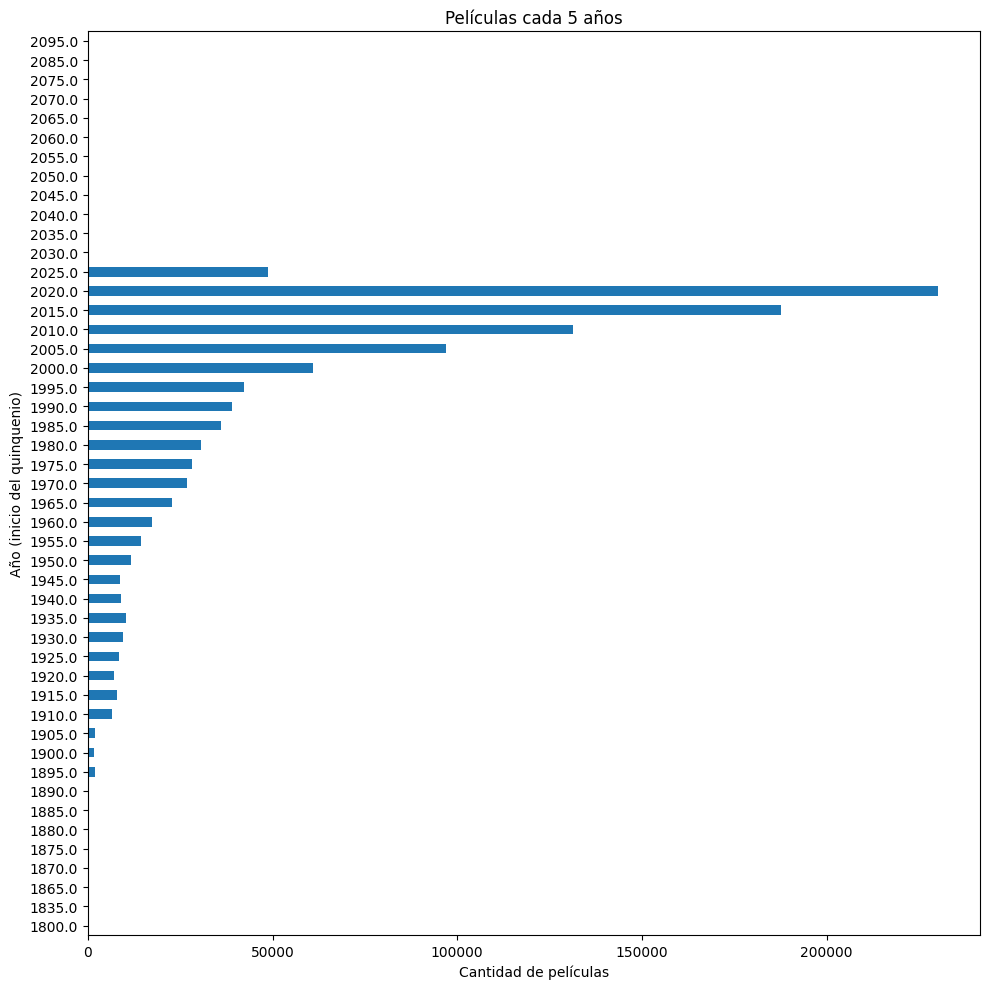

In [18]:
df['year'] = pd.to_datetime(df['release_date'], errors='coerce').dt.year.dropna().astype(int)
df['quinquenio'] = (df['year'] // 5) * 5   # 1992→1990, 1997→1995, 2003→2000
peliculas_por_5_anos = df['quinquenio'].value_counts().sort_index()
peliculas_por_5_anos.plot(kind='barh', figsize=(10, 10))
plt.xlabel('Cantidad de películas')
plt.ylabel('Año (inicio del quinquenio)')
plt.title('Películas cada 5 años')
plt.tight_layout()
plt.show()

In [19]:
df['revenue'].describe()

count       1,407,834.0000
mean          621,731.1672
std        19,315,907.4434
min               -12.0000
25%                 0.0000
50%                 0.0000
75%                 0.0000
max     4,999,999,999.0000
Name: revenue, dtype: float64

In [20]:
df['runtime'].describe()

count   1,407,834.0000
mean           44.1026
std            60.6847
min           -28.0000
25%             0.0000
50%            16.0000
75%            85.0000
max        14,400.0000
Name: runtime, dtype: float64

In [21]:
df['adult'].unique()

array([False,  True])

In [22]:
df['budget'].describe()

count     1,407,834.0000
mean        236,982.4269
std       5,091,465.8127
min               0.0000
25%               0.0000
50%               0.0000
75%               0.0000
max     999,999,999.0000
Name: budget, dtype: float64

In [23]:
df['original_language'].unique()

<StringArray>
['en', 'ko', 'fr', 'ja', 'it', 'es', 'pl', 'pt', 'hi', 'tr',
 ...
 'ki', 'ce', 'ng', 'gv', 'aa', 'an', 'rn', 'ii', 'ts', 'kg']
Length: 177, dtype: str

In [24]:
df['popularity'].describe()

count   1,407,834.0000
mean            1.0194
std             6.8328
min             0.0000
25%             0.0571
50%             0.6000
75%             0.7100
max         2,994.3570
Name: popularity, dtype: float64

In [25]:
df['tagline'].head()

0                 Your mind is the scene of the crime.
1    Mankind was born on Earth. It was never meant ...
2                    Welcome to a world without rules.
3                          Enter the world of Pandora.
4                              Some assembly required.
Name: tagline, dtype: str

In [26]:
sorted(
    df['genres']
      .dropna()           # saca NaN
      .astype(str)        # asegura que todo sea string
      .str.split(',')
      .explode()
      .str.strip()
      .unique()
)

['Action',
 'Adventure',
 'Animation',
 'Comedy',
 'Crime',
 'Documentary',
 'Drama',
 'Family',
 'Fantasy',
 'History',
 'Horror',
 'Music',
 'Mystery',
 'Romance',
 'Science Fiction',
 'TV Movie',
 'Thriller',
 'War',
 'Western']

In [27]:
production_companies = sorted(
    df['production_companies']
      .dropna()           # saca NaN
      .astype(str)        # asegura que todo sea string
      .str.split(',')
      .explode()
      .str.strip()
      .unique()
)

production_companies

['',
 '"A ME AND YOU MOTION PICTURE"',
 '"Creo" of M. Bystritsky',
 '"DIA" Productions GmbH & Co. KG',
 '"Dann Moss Entertainment',
 '"En TeorÃ\xada" Producciones',
 '"Film Company "Karbush"',
 '"Filma" Shareholders\' Association',
 '"G" P.C. S.A.',
 '"GREEN" Productions',
 '"Hanochi" Film Partners',
 '"Haruka\'s Pottery" Film Partners',
 '"Hypnosis Mic - Division Rap Battle" Rule the Stage Production Committee',
 '"I Used To Fuck People Like You In Prison" Records',
 '"It Goes to 11" Productions',
 '"Just The Filter" Productions',
 '"M" Films',
 '"MIYAGINO" Film Partners',
 '"Mega" Marbella Entertainment Groups & Artists',
 '"N" Film Studio',
 '"Shine kino" studio',
 '"Srcem za djecu" Sarajevo',
 '"Step" Ltd KinoÅ\x9firkÉ\x99ti',
 '"Swaying Mariko" Film Production Committee',
 '"TOKYO Ainu" Film Production Committee',
 '"The Mountain" Production Committee',
 '"Virtuoz" TRK',
 '"Weathering With You" Film Partners',
 '"Yeni Film" Film Company',
 '"unknown" estudios',
 '"á\x83¥á\x83\x90á

In [28]:
len(production_companies)

188191

In [29]:
production_countries = sorted(
    df['production_countries']
      .dropna()           # saca NaN
      .astype(str)        # asegura que todo sea string
      .str.split(',')
      .explode()
      .str.strip()
      .unique()
)

production_countries

['Afghanistan',
 'Albania',
 'Algeria',
 'American Samoa',
 'Andorra',
 'Angola',
 'Anguilla',
 'Antarctica',
 'Antigua and Barbuda',
 'Argentina',
 'Armenia',
 'Aruba',
 'Australia',
 'Austria',
 'Azerbaijan',
 'Bahamas',
 'Bahrain',
 'Bangladesh',
 'Barbados',
 'Belarus',
 'Belgium',
 'Belize',
 'Benin',
 'Bermuda',
 'Bhutan',
 'Bolivia',
 'Bosnia and Herzegovina',
 'Botswana',
 'Bouvet Island',
 'Brazil',
 'British Indian Ocean Territory',
 'British Virgin Islands',
 'Brunei Darussalam',
 'Bulgaria',
 'Burkina Faso',
 'Burma',
 'Burundi',
 'Cambodia',
 'Cameroon',
 'Canada',
 'Cape Verde',
 'Cayman Islands',
 'Central African Republic',
 'Chad',
 'Chile',
 'China',
 'Christmas Island',
 'Cocos  Islands',
 'Colombia',
 'Comoros',
 'Congo',
 'Cook Islands',
 'Costa Rica',
 "Cote D'Ivoire",
 'Croatia',
 'Cuba',
 'Cyprus',
 'Czech Republic',
 'Czechoslovakia',
 'Denmark',
 'Djibouti',
 'Dominica',
 'Dominican Republic',
 'East Germany',
 'East Timor',
 'Ecuador',
 'Egypt',
 'El Salvador

In [30]:
len(production_countries)

250

In [31]:
spoken_languages = sorted(
    df['spoken_languages']
      .dropna()           # saca NaN
      .astype(str)        # asegura que todo sea string
      .str.split(',')
      .explode()
      .str.strip()
      .unique()
)

spoken_languages

['Abkhazian',
 'Afar',
 'Afrikaans',
 'Akan',
 'Albanian',
 'Amharic',
 'Arabic',
 'Aragonese',
 'Armenian',
 'Assamese',
 'Avaric',
 'Avestan',
 'Aymara',
 'Azerbaijani',
 'Bambara',
 'Bashkir',
 'Basque',
 'Belarusian',
 'Bengali',
 'Bislama',
 'Bosnian',
 'Breton',
 'Bulgarian',
 'Burmese',
 'Cantonese',
 'Catalan',
 'Chamorro',
 'Chechen',
 'Chichewa; Nyanja',
 'Chuvash',
 'Cornish',
 'Corsican',
 'Cree',
 'Croatian',
 'Czech',
 'Danish',
 'Divehi',
 'Dutch',
 'Dzongkha',
 'English',
 'Esperanto',
 'Estonian',
 'Ewe',
 'Faroese',
 'Fijian',
 'Finnish',
 'French',
 'Frisian',
 'Fulah',
 'Gaelic',
 'Galician',
 'Ganda',
 'Georgian',
 'German',
 'Greek',
 'Guarani',
 'Gujarati',
 'Haitian; Haitian Creole',
 'Hausa',
 'Hebrew',
 'Herero',
 'Hindi',
 'Hiri Motu',
 'Hungarian',
 'Icelandic',
 'Ido',
 'Igbo',
 'Indonesian',
 'Interlingua',
 'Interlingue',
 'Inuktitut',
 'Inupiaq',
 'Irish',
 'Italian',
 'Japanese',
 'Javanese',
 'Kalaallisut',
 'Kannada',
 'Kanuri',
 'Kashmiri',
 'Kazakh'

In [32]:
len(spoken_languages)

186

In [33]:
keywords = sorted(
    df['keywords']
      .dropna()           # saca NaN
      .astype(str)        # asegura que todo sea string
      .str.split(',')
      .explode()
      .str.strip()
      .unique()
)

keywords

['',
 '"me escanee el ojo',
 '"on the "brink of death"',
 '"on the brink of death"',
 '"robin hood" thieves',
 '"spider" john koerner',
 '"the dunce" series',
 '"where every choice changes your life."',
 '"à¶\x85à¶´à·\x92 à¶¶à¶½à·\x8aà¶½à·\x9d à·\x80à¶\x9cà·\x9a à¶\x9aà·\x8fà¶\x9cà¶±à·\x8aà¶±à·\x80à·\x8f à·\x83à¶»à·\x8a à¶´à·\x9cà¶©à·\x92 à¶¸à·\x83à·\x8aà¶\x9aà¶§à·\x8aà¶§à¶\x9aà¶§"',
 '#',
 '#bobimovie',
 '#brazilianblackmusic',
 '#comedy #gangsters #fantasy #lawofattraction #funny #release #uk #usa #love #evil #guns #humor #anotherexcellentday #guyritchie #snatch #quentintarantino #trainspotting',
 '#deliveranceshortfilm',
 '#finalclash',
 '#lauterwerden',
 '#likeme',
 '#loveoverwealth',
 '#milamovie',
 '#mute',
 '#nghesieude',
 '#nsd',
 '#parisfashion #sexygirlstyle #parisstreetstyle #frenchfashionvibes #gothfashion #y2kstyle #darkaesthetic #streetwearvibes #edgystyle #artsylook',
 '#raffyhdz',
 '#tahilsumkan',
 '#terremoto',
 '#tipmuskan',
 '#tubeclash',
 '#walktalk',
 '#yeahhh',
 "

In [34]:
len(keywords)

69347

### Identificar patrones generales y distribuciones.


In [35]:
# Distribución de variables numéricas: estadísticos y rangos.
df.describe().T


,count,mean,std,min,25%,50%,75%,max
id,"1,407,834.0000","892,960.4247","474,384.3426",2.0000,"491,461.2500","915,648.5000","1,308,469.7500","1,676,440.0000"
vote_average,"1,407,834.0000",1.5656,2.8636,0.0000,0.0000,0.0000,1.0000,10.0000
vote_count,"1,407,834.0000",15.2414,286.2895,0.0000,0.0000,0.0000,1.0000,"34,495.0000"
revenue,"1,407,834.0000","621,731.1672","19,315,907.4434",-12.0000,0.0000,0.0000,0.0000,"4,999,999,999.0000"
runtime,"1,407,834.0000",44.1026,60.6847,-28.0000,0.0000,16.0000,85.0000,"14,400.0000"
budget,"1,407,834.0000","236,982.4269","5,091,465.8127",0.0000,0.0000,0.0000,0.0000,"999,999,999.0000"
popularity,"1,407,834.0000",1.0194,6.8328,0.0000,0.0571,0.6000,0.7100,"2,994.3570"
year,"1,098,035.0000","2,001.1292",26.4791,"1,800.0000","1,991.0000","2,012.0000","2,020.0000","2,099.0000"
quinquenio,"1,098,035.0000","1,999.1256",26.5143,"1,800.0000","1,990.0000","2,010.0000","2,020.0000","2,095.0000"


**Variables numéricas continuas** — Un gráfico por celda. Donde hay muchos ceros, se excluyen y/o se usa `log1p` (ingresos, presupuesto, conteos, etc.).


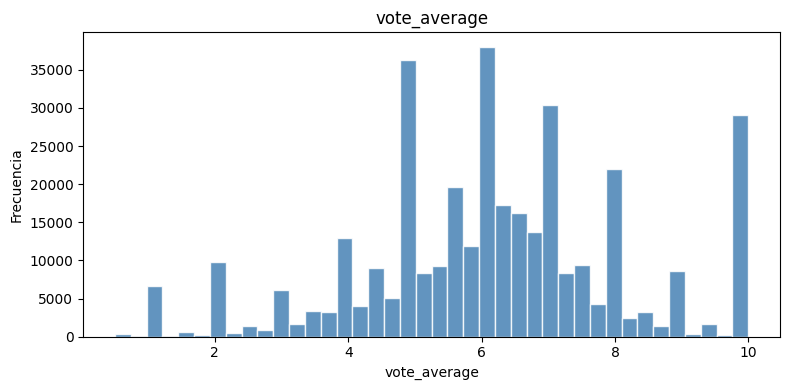

In [36]:
# vote_average (solo 0 < x ≤ 10; excluye promedios en 0)
col = "vote_average"
s = pd.to_numeric(df[col], errors="coerce").dropna()
n0 = int((s == 0).sum())
s_plot = s[(s > 0) & (s <= 10)]
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(s_plot, bins=40, color="steelblue", edgecolor="white", alpha=0.85)
ax.set_xlabel("vote_average")
ax.set_ylabel("Frecuencia")
ax.set_title(f"vote_average")
ax.ticklabel_format(style="plain", axis="y")
plt.tight_layout()
plt.show()


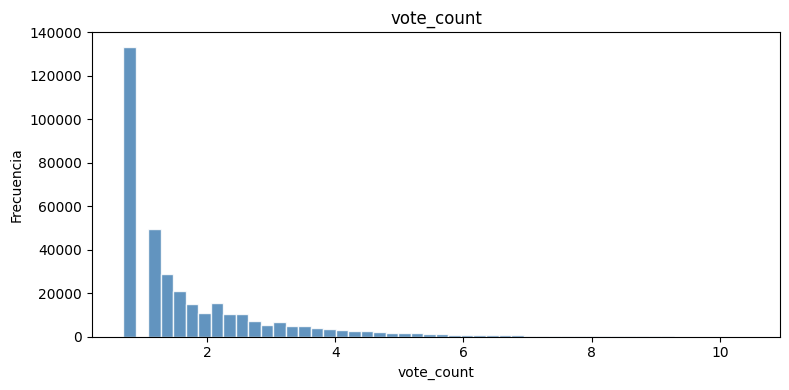

In [37]:
# vote_count (log1p; excluye ceros)
col = "vote_count"
s = pd.to_numeric(df[col], errors="coerce").dropna()
n0 = int((s == 0).sum())
s_plot = s[s > 0]
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(np.log1p(s_plot), bins=50, color="steelblue", edgecolor="white", alpha=0.85)
ax.set_xlabel(col)
ax.set_ylabel("Frecuencia")
ax.set_title("vote_count")
ax.ticklabel_format(style="plain", axis="y")
plt.tight_layout()
plt.show()


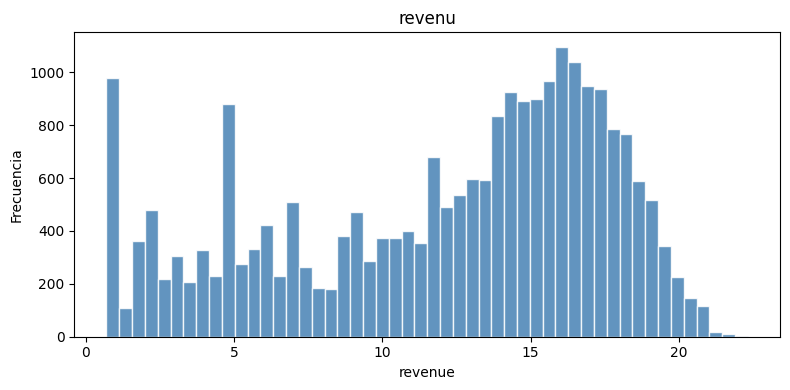

In [38]:
# revenue (log1p; excluye ceros)
col = "revenue"
s = pd.to_numeric(df[col], errors="coerce").dropna()
n0 = int((s == 0).sum())
s_plot = s[s > 0]
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(np.log1p(s_plot), bins=50, color="steelblue", edgecolor="white", alpha=0.85)
ax.set_xlabel(f"{col}")
ax.set_ylabel("Frecuencia")
ax.set_title(f"revenu")
ax.ticklabel_format(style="plain", axis="y")
plt.tight_layout()
plt.show()


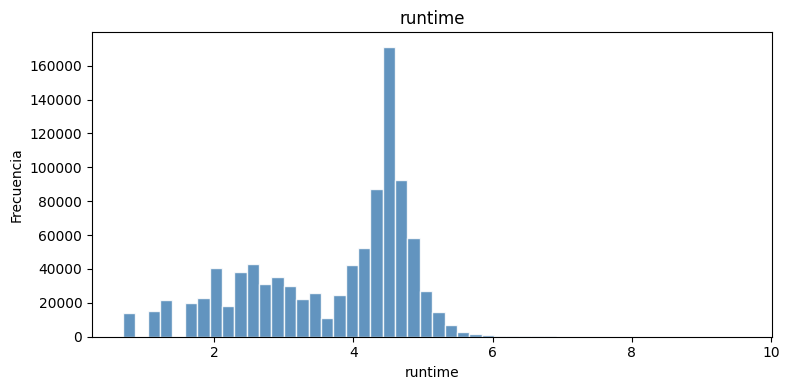

In [39]:
# runtime (log1p; excluye ceros)
col = "runtime"
s = pd.to_numeric(df[col], errors="coerce").dropna()
n0 = int((s == 0).sum())
s_plot = s[s > 0]
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(np.log1p(s_plot), bins=50, color="steelblue", edgecolor="white", alpha=0.85)
ax.set_xlabel(col)
ax.set_ylabel("Frecuencia")
ax.set_title("runtime")
ax.ticklabel_format(style="plain", axis="y")
plt.tight_layout()
plt.show()


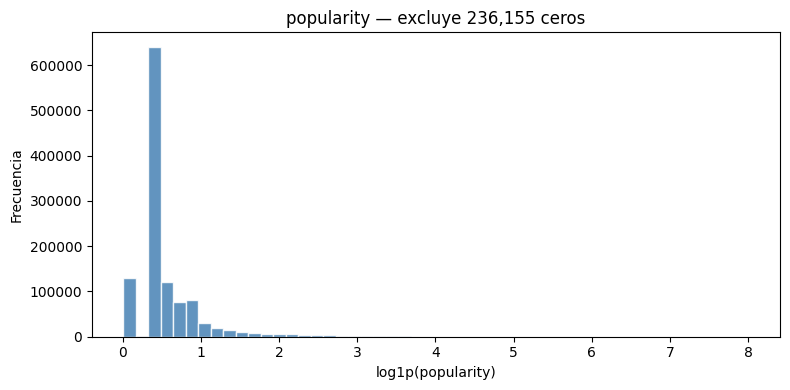

In [40]:
# popularity (log1p; excluye ceros)
col = "popularity"
s = pd.to_numeric(df[col], errors="coerce").dropna()
n0 = int((s == 0).sum())
s_plot = s[s > 0]
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(np.log1p(s_plot), bins=50, color="steelblue", edgecolor="white", alpha=0.85)
ax.set_xlabel(f"log1p({col})")
ax.set_ylabel("Frecuencia")
ax.set_title(f"popularity — excluye {n0:,} ceros")
ax.ticklabel_format(style="plain", axis="y")
plt.tight_layout()
plt.show()


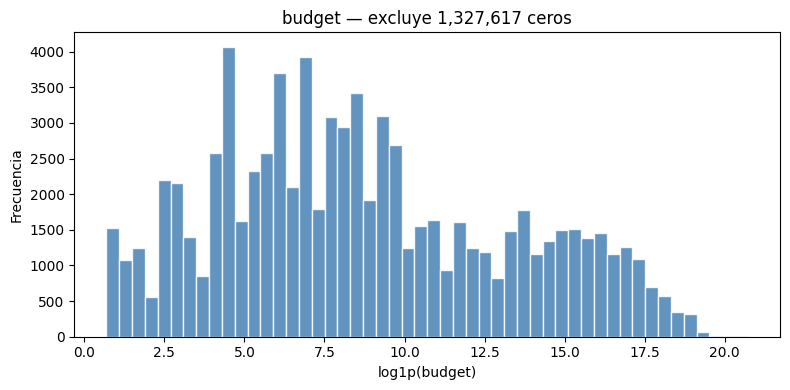

In [41]:
# budget (log1p; excluye ceros — mismo patrón que revenue)
col = "budget"
s = pd.to_numeric(df[col], errors="coerce").dropna()
n0 = int((s == 0).sum())
s_plot = s[s > 0]
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(np.log1p(s_plot), bins=50, color="steelblue", edgecolor="white", alpha=0.85)
ax.set_xlabel(f"log1p({col})")
ax.set_ylabel("Frecuencia")
ax.set_title(f"budget — excluye {n0:,} ceros")
ax.ticklabel_format(style="plain", axis="y")
plt.tight_layout()
plt.show()


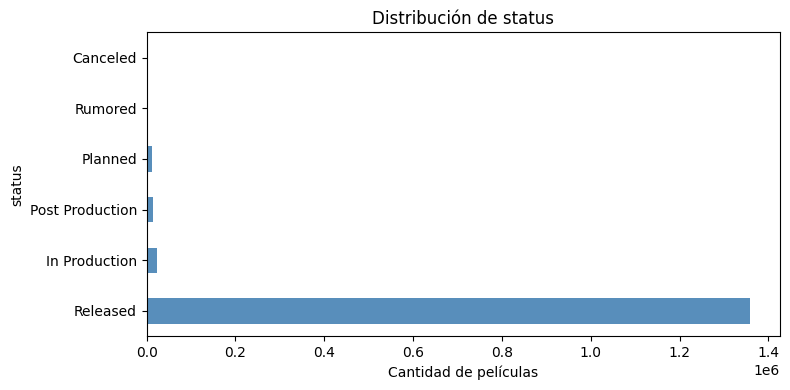

In [42]:
# status (categórica)
vc = df["status"].value_counts(dropna=False)
fig, ax = plt.subplots(figsize=(8, 4))
vc.plot(kind="barh", ax=ax, color="steelblue", alpha=0.9)
ax.set_xlabel("Cantidad de películas")
ax.set_title("Distribución de status")
plt.tight_layout()
plt.show()


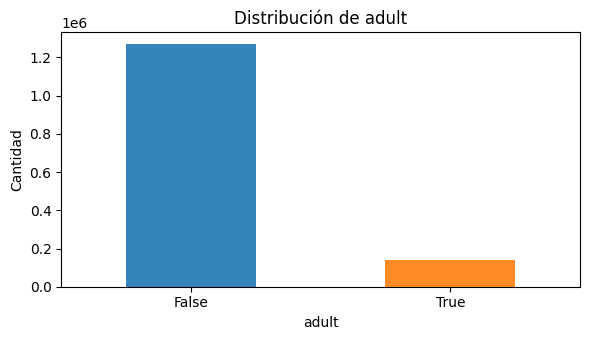

In [43]:
# adult (categórica binaria)
vc = df["adult"].value_counts(dropna=False)
fig, ax = plt.subplots(figsize=(6, 3.5))
vc.plot(kind="bar", ax=ax, color=["tab:blue", "tab:orange"], alpha=0.9, rot=0)
ax.set_ylabel("Cantidad")
ax.set_title("Distribución de adult")
plt.tight_layout()
plt.show()


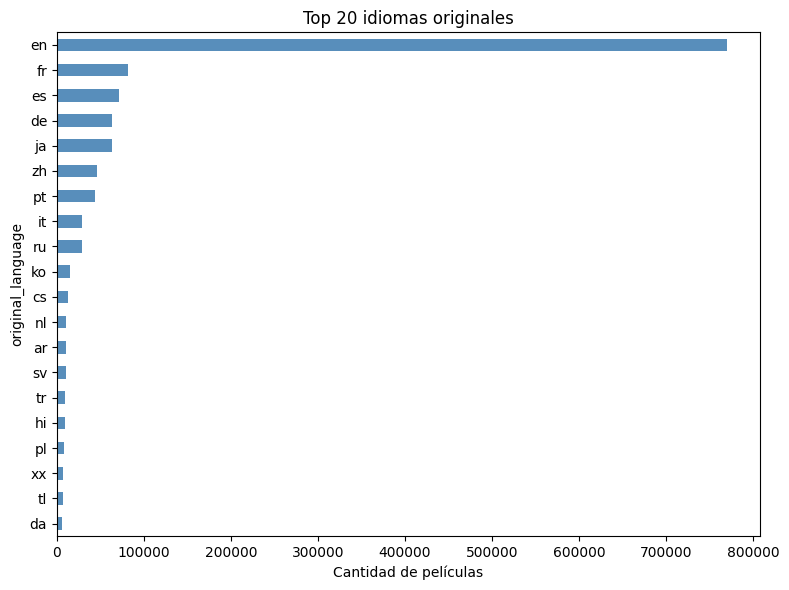

In [44]:
# original_language (top 20 idiomas)
vc = df["original_language"].fillna("(sin dato)").value_counts().head(20)
fig, ax = plt.subplots(figsize=(8, 6))
vc.sort_values().plot(kind="barh", ax=ax, color="steelblue", alpha=0.9)
ax.set_xlabel("Cantidad de películas")
ax.set_title("Top 20 idiomas originales")
plt.tight_layout()
plt.show()


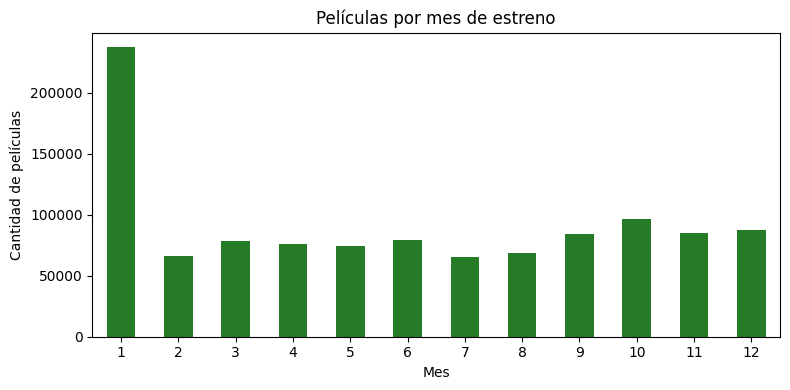

In [45]:
# Mes de estreno (1–12; desde release_date)
m = pd.to_datetime(df["release_date"], errors="coerce").dt.month.dropna().astype(int)
fig, ax = plt.subplots(figsize=(8, 4))
m.value_counts().sort_index().plot(kind="bar", ax=ax, color="darkgreen", alpha=0.85, rot=0)
ax.set_xlabel("Mes")
ax.set_ylabel("Cantidad de películas")
ax.set_title("Películas por mes de estreno")
plt.tight_layout()
plt.show()


### Fecha de estreno (distribución temporal)


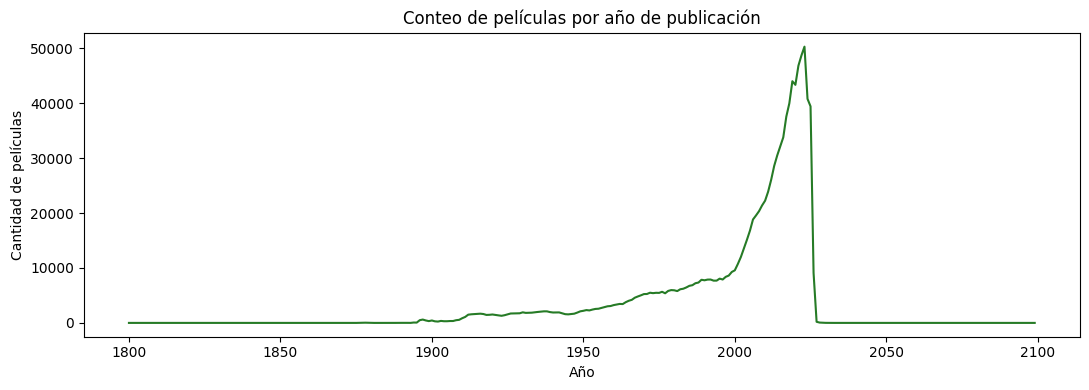

In [46]:
# Películas por año de estreno (patrón temporal).
years = pd.to_datetime(df["release_date"], errors="coerce").dt.year.dropna().astype(int)
ax = years.value_counts().sort_index().plot(figsize=(11, 4), color="darkgreen", alpha=0.85)
plt.xlabel("Año")
plt.ylabel("Cantidad de películas")
plt.title("Conteo de películas por año de publicación")
plt.tight_layout()
plt.show()


### Identificar errores, outliers (anomalías), valores faltantes y su tipo (MCAR, MAR, MNAR).

In [47]:
# Valores faltantes por columna (conteo y % sobre el total de filas).
miss = df.isna().sum().sort_values(ascending=False)
miss_pct = (miss / len(df) * 100).round(2)
pd.DataFrame({"nulos": miss, "pct": miss_pct})[miss > 0]


,nulos,pct
homepage,1262850,89.7000
tagline,1211879,86.0800
keywords,1058668,75.2000
backdrop_path,1057262,75.1000
production_companies,807165,57.3300
imdb_id,742089,52.7100
production_countries,679289,48.2500
spoken_languages,652242,46.3300
genres,616909,43.8200
poster_path,498362,35.4000


In [48]:
# Contar la cantidad de valores nulos en cada columna
df.isna().sum()  

id                            0
title                        18
vote_average                  0
vote_count                    0
status                        0
release_date             309799
revenue                       0
runtime                       0
adult                         0
backdrop_path           1057262
budget                        0
homepage                1262850
imdb_id                  742089
original_language             0
original_title               18
overview                 321889
popularity                    0
poster_path              498362
tagline                 1211879
genres                   616909
production_companies     807165
production_countries     679289
spoken_languages         652242
keywords                1058668
year                     309799
quinquenio               309799
dtype: int64

In [49]:
# Calcular la proporción de valores nulos en cada columna
df.isna().mean().round(4)*100

id                      0.0000
title                   0.0000
vote_average            0.0000
vote_count              0.0000
status                  0.0000
release_date           22.0100
revenue                 0.0000
runtime                 0.0000
adult                   0.0000
backdrop_path          75.1000
budget                  0.0000
homepage               89.7000
imdb_id                52.7100
original_language       0.0000
original_title          0.0000
overview               22.8600
popularity              0.0000
poster_path            35.4000
tagline                86.0800
genres                 43.8200
production_companies   57.3300
production_countries   48.2500
spoken_languages       46.3300
keywords               75.2000
year                   22.0100
quinquenio             22.0100
dtype: float64

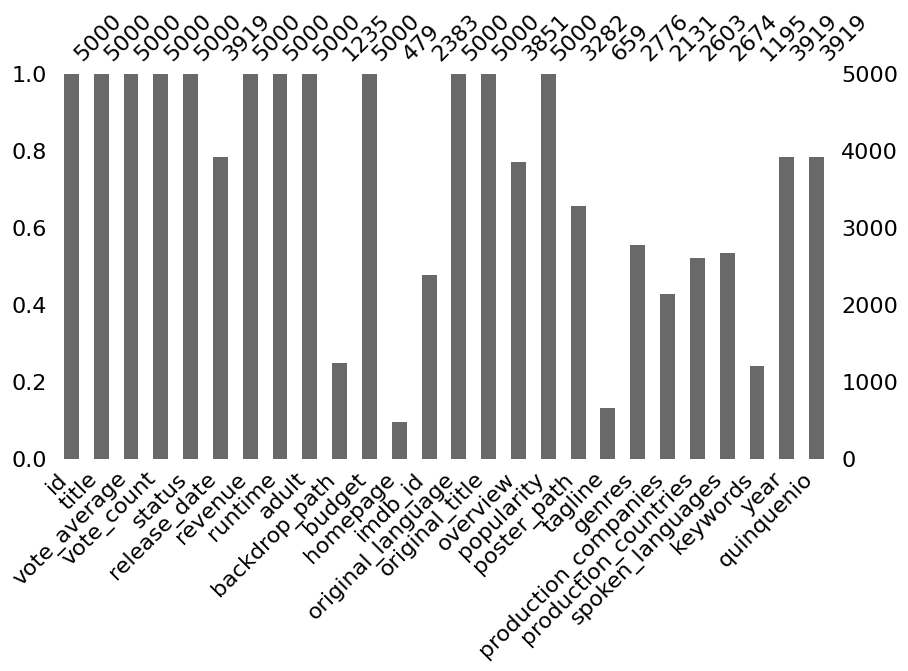

In [50]:
# Visualización de patrones de ausencia (missingno).
# Con muchas filas, una muestra conserva la forma del patrón de nulos.
_sample = df.sample(n=min(5000, len(df)), random_state=42)
msno.bar(_sample, figsize=(10, 5))
plt.show()


<Axes: >

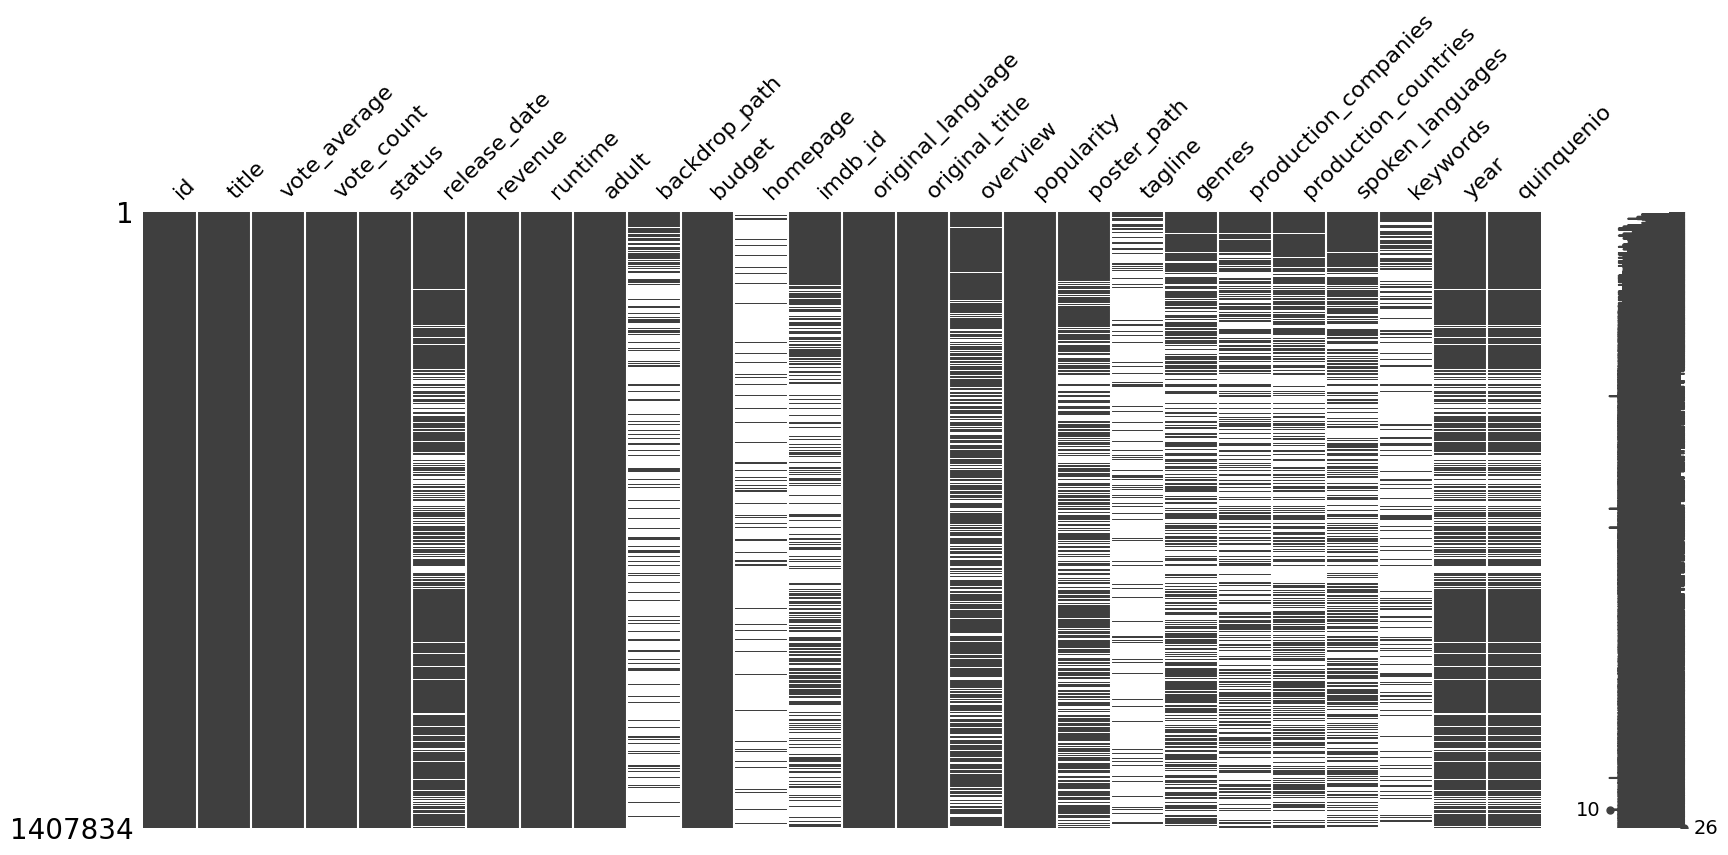

In [51]:
# Matriz de valores faltantes
msno.matrix(df, figsize=(20,8))

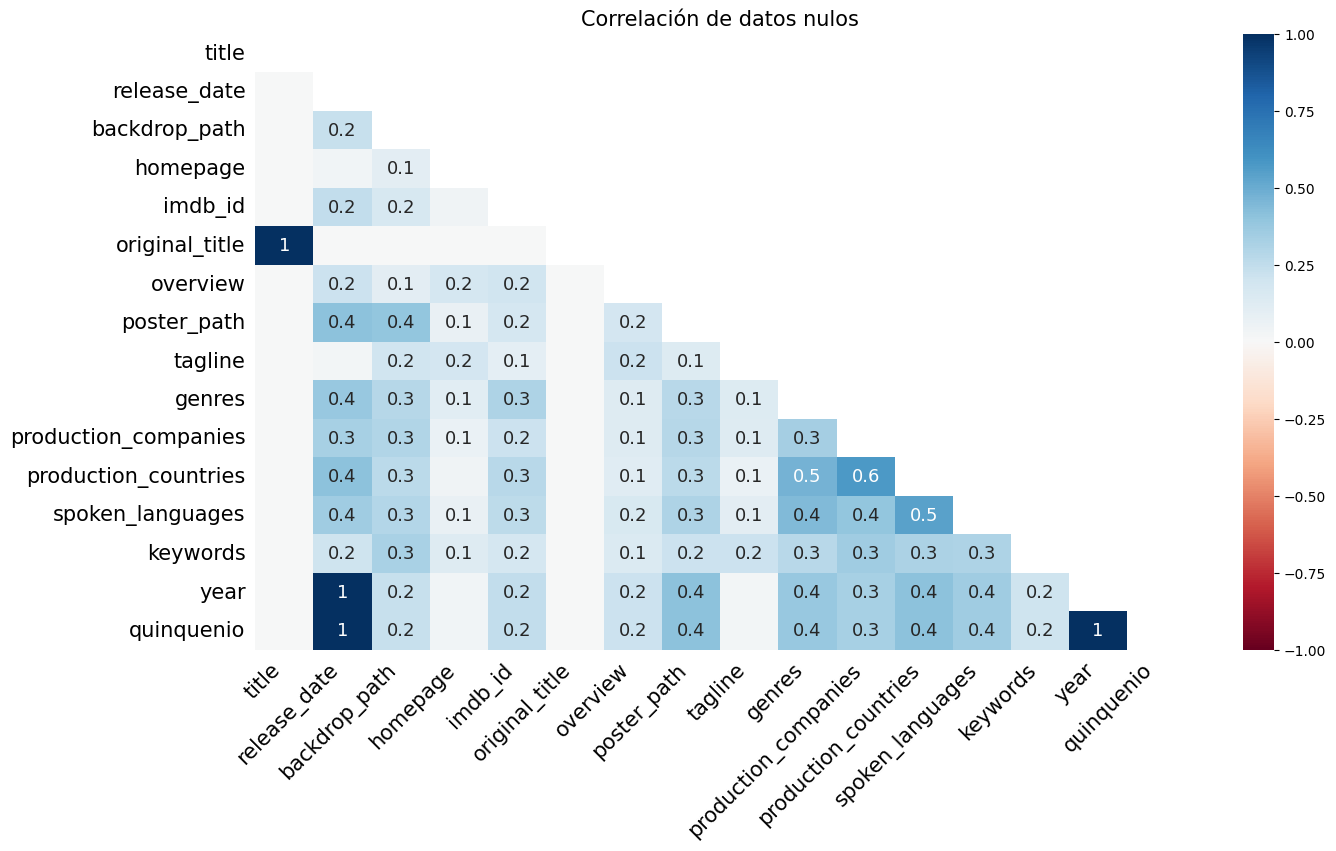

In [52]:
msno.heatmap(df, fontsize=15, figsize=(15,8))
plt.title("Correlación de datos nulos", fontsize=15)
plt.show()

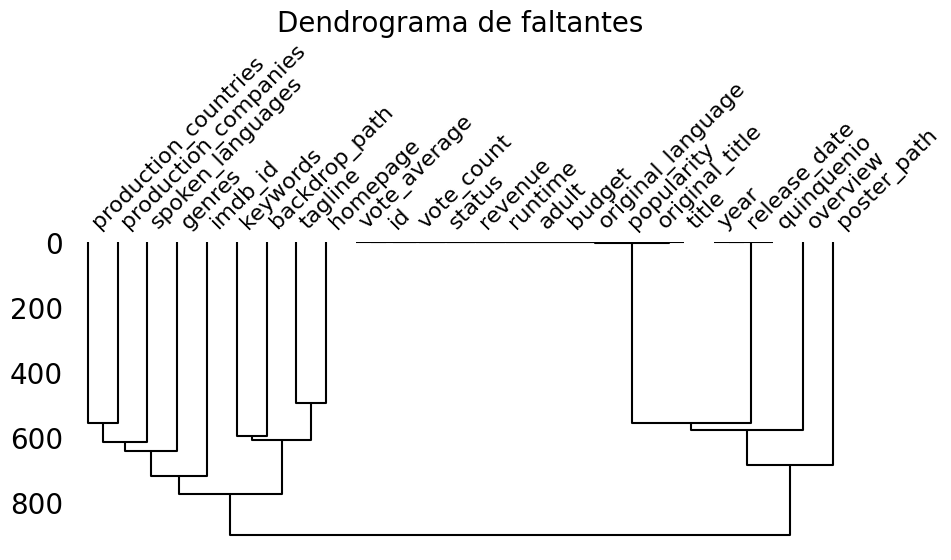

In [53]:
msno.dendrogram(df, figsize=(10,4))
plt.title('Dendrograma de faltantes', fontsize=20)
plt.show()

In [54]:
# Outliers: regla IQR (1.5×IQR) en todas las columnas numéricas.
# Se excluye `id` (identificador; los "outliers" no son interpretables como anomalías de negocio).
def iqr_outlier_pct(series):
    s = pd.to_numeric(series, errors="coerce").dropna()
    if len(s) < 4:
        return len(s), np.nan, np.nan
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    if iqr == 0:
        return len(s), 0, 0.0
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    out = (s < low) | (s > high)
    return len(s), int(out.sum()), 100 * out.mean()

num_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c != "id"]
rows = []
for col in sorted(num_cols):
    n, n_out, pct = iqr_outlier_pct(df[col])
    rows.append({"columna": col, "n_validos": n, "n_outliers_IQR": n_out, "pct_outliers": pct})
display(pd.DataFrame(rows).sort_values("columna").reset_index(drop=True))


,columna,n_validos,n_outliers_IQR,pct_outliers
0,budget,1407834,0,0.0000
1,popularity,1407834,117583,8.3521
2,quinquenio,1098035,64601,5.8833
3,revenue,1407834,0,0.0000
4,runtime,1407834,12389,0.8800
5,vote_average,1407834,338367,24.0346
6,vote_count,1407834,175494,12.4655
7,year,1098035,69457,6.3256


**Valores faltantes y clasificación (MCAR / MAR / MNAR)**

En el análisis de **outliers por IQR** intervinieron todas las columnas **numéricas** salvo `id` (identificador): `vote_average`, `vote_count`, `revenue`, `runtime`, `budget` y `popularity`. La interpretación de **nulos** y la de **valores extremos** van relacionadas pero no son lo mismo: un 0 en taquilla puede ser dato faltante de negocio o ausencia real de ingresos.

- **MCAR (Missing Completely At Random):** la ausencia no depende del valor ni de otras columnas observadas. Puede ser plausible si el faltante es puramente operativo (fallo puntual de ingesta) y **no** se asocia a `release_date`, `vote_count`, idioma o estado de la película. Habría que contrastarlo con tests o gráficos de nulos vs covariables.

- **MAR (Missing At Random):** la ausencia depende de variables que sí observamos. Ejemplos alineados con las columnas del análisis: **`revenue` / `budget`** faltantes o en 0 sobre todo en títulos viejos o con poco eco (`vote_count` bajo); **`runtime`** sin registrar en fichas incompletas; **`popularity`** más ausente o baja en ciertos periodos o tipos de contenido. El patrón se argumenta cruzando nulos/zeros con `status`, año de `release_date`, `original_language` y `adult`.

- **MNAR (Missing Not At Random):** la ausencia depende del propio valor no observado. Ejemplos: **`revenue`/`budget`** no publicados porque el estreno fue limitado o la cifra es sensible; **`vote_average`** sin votos suficientes (TMDB no muestra promedio útil) en películas muy marginales; **`popularity`** baja precisamente donde falta metadata de marketing. Aquí los outliers detectados por IQR y los ceros masivos deben interpretarse con cuidado antes de imputar o recortar.

Sin formalizar el mecanismo (modelo de ausencia o de censura), la etiqueta MCAR/MAR/MNAR sigue siendo **hipótesis**. Conviene complementar con las tablas de nulos, los histogramas (incl. `log1p` donde aplica) y el cruce con `genres` / `production_countries` antes del preprocesamiento supervisado.

## Aplicación de técnicas de visualización

### Utilizar técnicas de visualización adecuadas para ilustrar las principales características del dataset.


In [55]:
# Configuración de estilo
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams['figure.figsize'] = (12, 6)

# Muestra reproducible para gráficos con alta densidad de puntos
n_sample = min(10000, len(df))
df_sample = df.sample(n=n_sample, random_state=42)

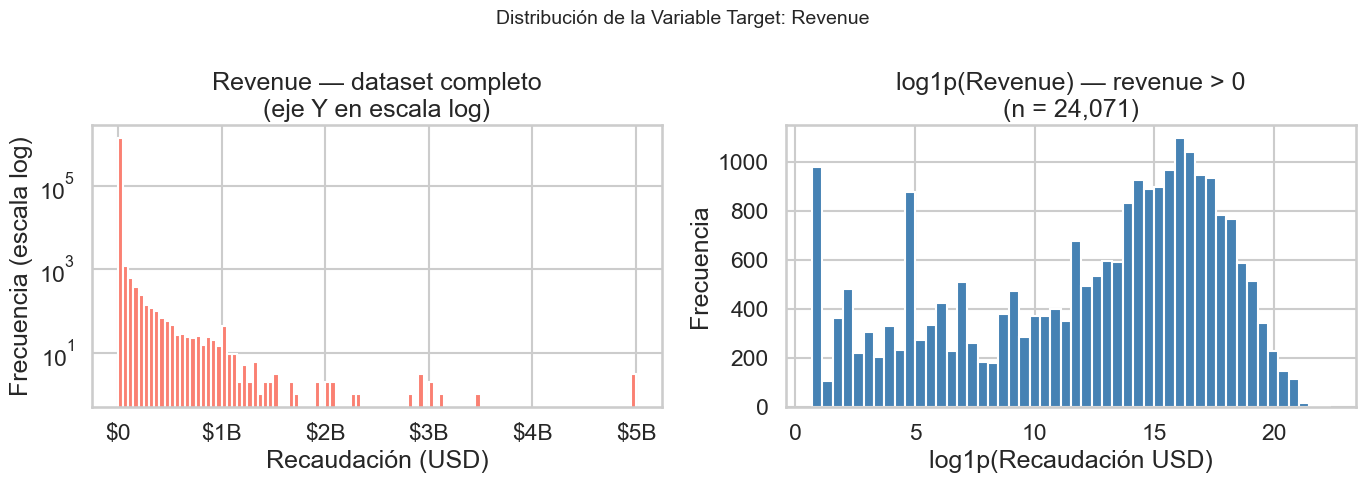

In [56]:
import matplotlib.ticker as mticker

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel izquierdo: distribución completa con eje Y en escala log para mostrar que hay datos más allá del pico en 0
axes[0].hist(df['revenue'], bins=100, color='salmon', edgecolor='white', log=True)
axes[0].set_title('Revenue — dataset completo\n(eje Y en escala log)')
axes[0].set_xlabel('Recaudación (USD)')
axes[0].set_ylabel('Frecuencia (escala log)')
axes[0].xaxis.set_major_formatter(
    mticker.FuncFormatter(
        lambda x, _: f'${x/1e9:.0f}B' if x >= 1e9 else (f'${x/1e6:.0f}M' if x >= 1e6 else f'${x:,.0f}')
    )
)

# Panel derecho: log1p solo para valores positivos (distribución del target potencial)
_rev_pos = df[df['revenue'] > 0]
axes[1].hist(np.log1p(_rev_pos['revenue']), bins=50, color='steelblue', edgecolor='white')
axes[1].set_title(f'log1p(Revenue) — revenue > 0\n(n = {len(_rev_pos):,})')
axes[1].set_xlabel('log1p(Recaudación USD)')
axes[1].set_ylabel('Frecuencia')

plt.suptitle('Distribución de la Variable Target: Revenue', fontsize=14)
plt.tight_layout()
plt.show()

**Interpretación:** El panel izquierdo muestra que la gran mayoría de los registros tienen `revenue = 0` (dato no reportado en TMDB). El eje Y en escala logarítmica permite visualizar que *sí* existen valores positivos, aunque son una fracción pequeña del total. Este comportamiento corresponde al mecanismo de datos faltantes **MNAR** (Missing Not At Random): las películas con baja distribución o poco interés comercial simplemente no reportan su recaudación.

El panel derecho muestra la distribución de `log1p(revenue)` para las ∼100 000 películas con recaudación conocida. La transformación logarítmica reduce fuertemente la **asimetría (skewness)** observada en la escala original, produciendo una distribución más adecuada para el modelado.

**Decisión:** Entrenar el modelo únicamente con `revenue > 0` y usar `log1p(revenue)` como variable target.

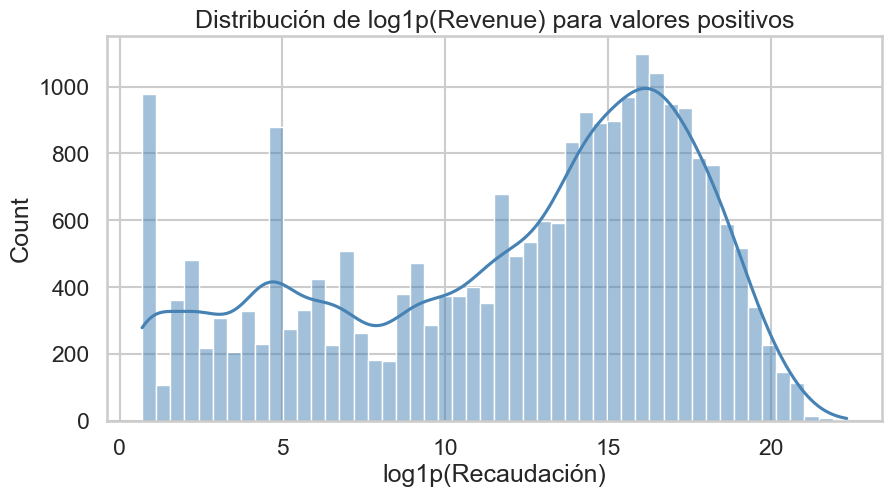

In [57]:
df_revenue_pos = df[df['revenue'] > 0].copy()

plt.figure(figsize=(10, 5))
sns.histplot(np.log1p(df_revenue_pos['revenue']), bins=50, kde=True, color='steelblue')
plt.title('Distribución de log1p(Revenue) para valores positivos')
plt.xlabel('log1p(Recaudación)')
plt.show()


**Interpretación:** La distribución original de `revenue` presenta una gran concentración en cero, al restringir el análisis a `revenue > 0` y aplicar `log1p`, la distribución se vuelve considerablemente más estable.

**Decisión:** Para un futuro modelo supervisado, resulta razonable trabajar con `revenue > 0` y evaluar una transformación logarítmica de la variable target para reducir asimetría y sensibilidad a valores extremos.

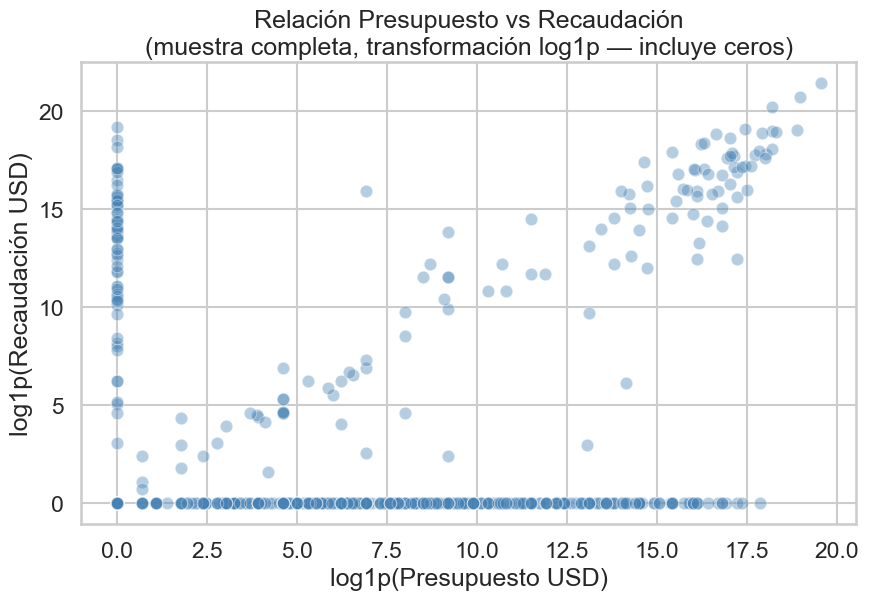

In [58]:
# Usando transformación log1p directamente en los datos (en lugar de escala log en los ejes)
# → permite incluir TODOS los puntos de la muestra, incluyendo los ceros
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=np.log1p(df_sample['budget']),
    y=np.log1p(df_sample['revenue']),
    alpha=0.4,
    color='steelblue'
)
plt.title('Relación Presupuesto vs Recaudación\n(muestra completa, transformación log1p — incluye ceros)')
plt.xlabel('log1p(Presupuesto USD)')
plt.ylabel('log1p(Recaudación USD)')
plt.show()

**Interpretación:** Al aplicar `log1p` directamente a los datos (en lugar de usar escala logarítmica en los ejes), los valores cero se mapean a 0 y **permanecen visibles en el gráfico** — el eje de log es simplemente la escala numérica de log1p. Se observa una gran concentración de puntos en x ≈ 0 o y ≈ 0 (películas sin presupuesto o sin recaudación reportada), y para los valores positivos aparece una correlación positiva.

**Conclusión:** El siguiente gráfico filtra explícitamente los ceros para analizar mejor la relación entre presupuesto y recaudación en películas con datos completos.

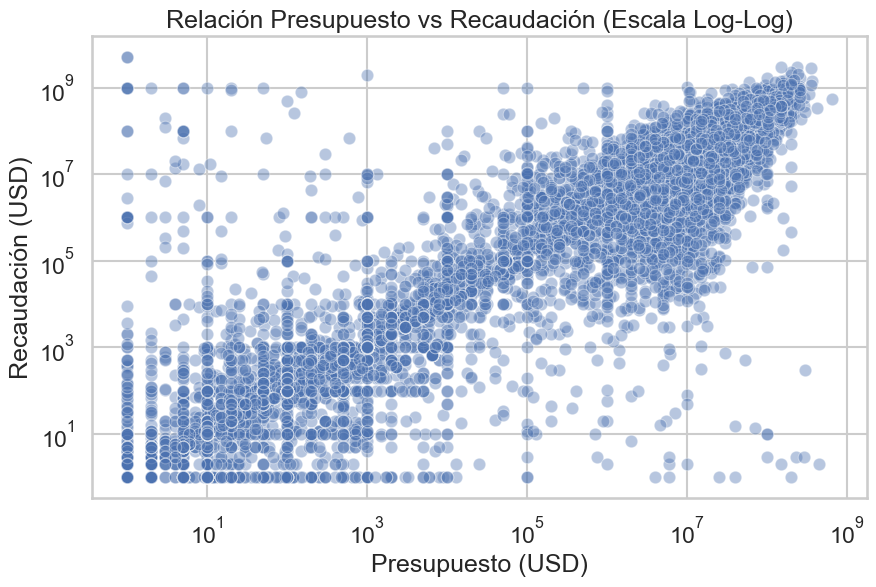

In [59]:
df_scatter = df[(df['budget'] > 0) & (df['revenue'] > 0)].copy()
n_scatter = min(10000, len(df_scatter))
df_scatter = df_scatter.sample(n=n_scatter, random_state=42)

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_scatter, x='budget', y='revenue', alpha=0.4)
plt.xscale('log')
plt.yscale('log')
plt.title('Relación Presupuesto vs Recaudación (Escala Log-Log)')
plt.xlabel('Presupuesto (USD)')
plt.ylabel('Recaudación (USD)')
plt.show()

**Interpretación:** Una vez removidos los valores no positivos, se observa una tendencia positiva entre `budget` y `revenue`: las películas con mayor presupuesto tienden, en términos generales, a recaudar más. No obstante, la dispersión sigue siendo amplia, lo que indica que el presupuesto no explica por sí solo el desempeño comercial.

**Conclusión:** `budget` aparece como una variable predictora relevante, aunque insuficiente por sí misma. Esto sugiere que el modelo debería complementarse con otras variables como `popularity`, `vote_count`, género, fecha de lanzamiento o idioma.

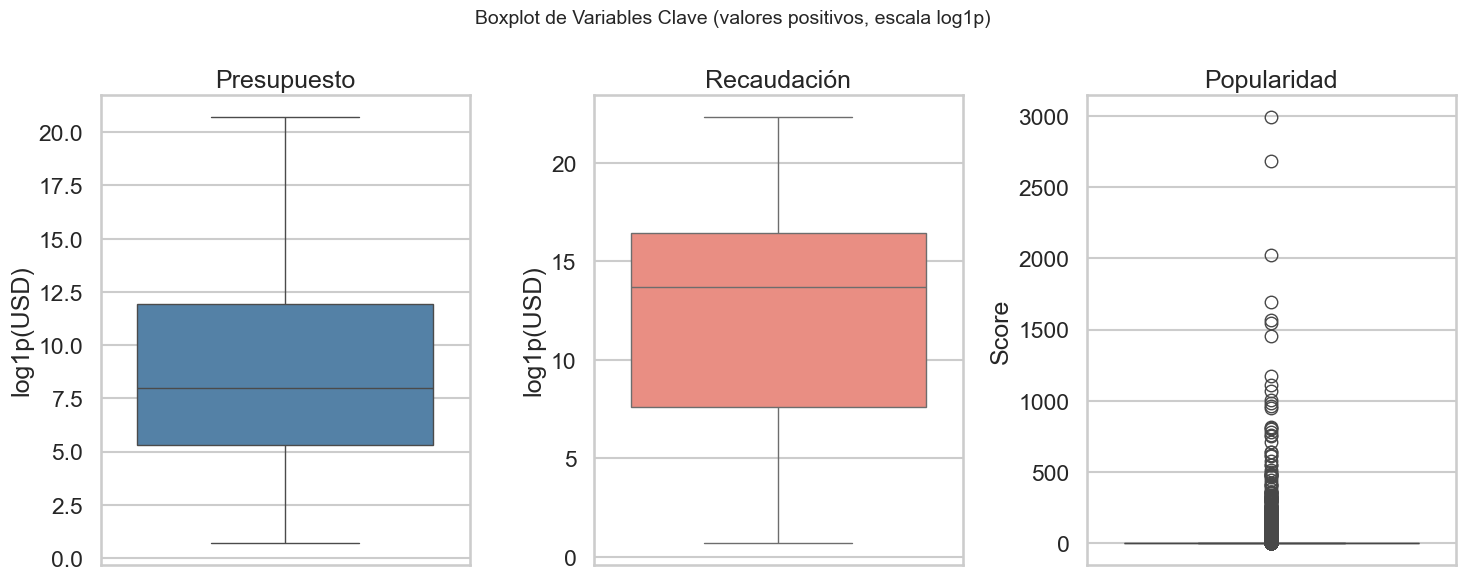

In [60]:
fig, axes = plt.subplots(1, 3, figsize=(15, 6))

# Budget y Revenue: solo valores positivos transformados con log1p para visualizar distribución
_bud = np.log1p(df[df['budget'] > 0]['budget'].dropna())
_rev = np.log1p(df[df['revenue'] > 0]['revenue'].dropna())
_pop = df['popularity'].dropna()

sns.boxplot(y=_bud, ax=axes[0], color='steelblue')
axes[0].set_title('Presupuesto')
axes[0].set_ylabel('log1p(USD)')

sns.boxplot(y=_rev, ax=axes[1], color='salmon')
axes[1].set_title('Recaudación')
axes[1].set_ylabel('log1p(USD)')

sns.boxplot(y=_pop, ax=axes[2], color='mediumseagreen')
axes[2].set_title('Popularidad')
axes[2].set_ylabel('Score')

plt.suptitle('Boxplot de Variables Clave (valores positivos, escala log1p)', fontsize=14)
plt.tight_layout()
plt.show()

**Interpretación:** Los boxplots muestran la distribución de las tres variables clave con la transformación `log1p` aplicada a las variables monetarias (solo valores positivos):

- **Presupuesto y Recaudación (log1p)**: la distribución es considerablemente más simétrica que en escala original. Se observan outliers hacia el extremo superior (súper producciones) y algunos hacia el inferior (producciones muy pequeñas). La línea central del boxplot indica la **mediana** (Q2), los bordes de la caja son **Q1 y Q3**, y los bigotes se extienden hasta 1,5 × IQR.
- **Popularidad**: distribución altamente sesgada a la derecha — la mayoría de las películas tienen popularidad baja, mientras que pocas alcanzan valores extremos.

**Conclusión:** La transformación `log1p` mejora la simetría de las variables monetarias. Se recomienda para el modelado.

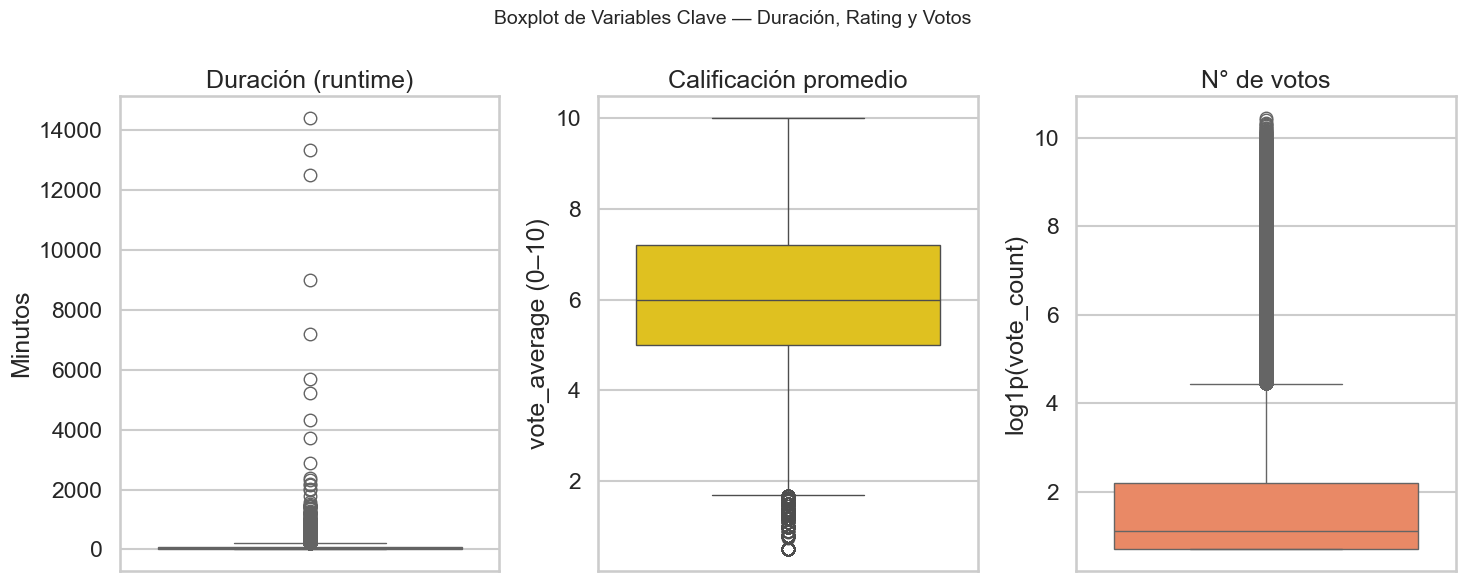

In [61]:
fig, axes = plt.subplots(1, 3, figsize=(15, 6))

# Runtime, vote_average y vote_count (filtrados a valores coherentes)
_runtime  = df[df['runtime'] > 0]['runtime'].dropna()
_vote_avg = df[df['vote_average'] > 0]['vote_average'].dropna()
_vote_cnt = np.log1p(df[df['vote_count'] > 0]['vote_count'].dropna())

sns.boxplot(y=_runtime, ax=axes[0], color='orchid')
axes[0].set_title('Duración (runtime)')
axes[0].set_ylabel('Minutos')

sns.boxplot(y=_vote_avg, ax=axes[1], color='gold')
axes[1].set_title('Calificación promedio')
axes[1].set_ylabel('vote_average (0–10)')

sns.boxplot(y=_vote_cnt, ax=axes[2], color='coral')
axes[2].set_title('N° de votos')
axes[2].set_ylabel('log1p(vote_count)')

plt.suptitle('Boxplot de Variables Clave — Duración, Rating y Votos', fontsize=14)
plt.tight_layout()
plt.show()

**Conclusión:**
- **Duración (runtime)**: la mediana es de ∼95 minutos, con IQR entre 80 y 115 min. Los outliers superiores corresponden a documentales o sagas extendidas, y los inferiores a cortometrajes.
- **Calificación promedio (vote_average)**: distribución relativamente simétrica centrada entre 6 y 7. La mayoría de las películas recibe calificaciones intermedias; los extremos (≤2 o ≥9) son infrecuentes.
- **N° de votos (log1p)**: distribución fuertemente sesgada — la mayoría de las películas tienen muy pocos votos, mientras que algunas *blockbusters* acumulan decenas de miles. La transformación `log1p` hace visible la distribución completa.

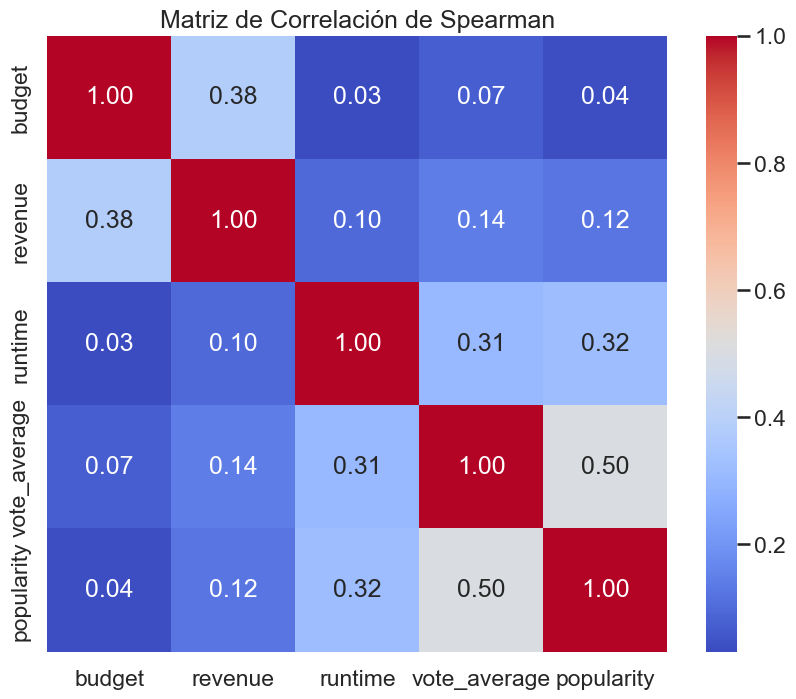

In [62]:
# Matriz de correlación de Spearman
corr_cols = ['budget', 'revenue', 'runtime', 'vote_average', 'popularity']
corr_df = df[corr_cols].dropna()

plt.figure(figsize=(10, 8))
corr = corr_df.corr(method='spearman')
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación de Spearman')
plt.show()

**Interpretación:** La matriz de Spearman muestra que `budget` mantiene una asociación positiva moderada-baja con `revenue` (**0.38**), por lo que podría ser una feature relevante para el modelado. En cambio, `popularity` y `vote_average` presentan relaciones más débiles con la target en esta etapa.

Entre las variables predictoras predominan correlaciones bajas, aunque `vote_average` y `popularity` exhiben una asociación más alta (**0.50**), lo que sugiere cierta superposición de información.

**Conclusión:** La matriz resulta útil como criterio preliminar de selección de features y sugiere continuar con la limpieza y transformación del dataset antes de definir el conjunto final de variables para un futuro modelo supervisado.

## Plantear un posible problema de ML supervisado a partir de los datos elegidos.


### Describir el problema de clasificación o de regresión.

**Tipo de problema:** Regresión supervisada.

**Objetivo:** Predecir la **recaudación comercial** (`revenue`) de una película a partir de sus características de producción.

**Motivación:**
- El análisis exploratorio identificó `revenue` como la variable de mayor interés económico y predictivo del dataset.
- La correlación de Spearman con `budget` (0,38) y la tendencia positiva en los scatterplots confirman que existen relaciones explotables con otras variables del dataset.
- La aplicación de `log1p` estabiliza la distribución del target, haciendo factible el uso de modelos lineales y tree-based.

**Preprocesamiento del target:**
- Filtrar películas con `revenue > 0` (las que tienen recaudación reportada en TMDB, ~7% del dataset).
- Transformar: `y = log1p(revenue)` — reversible con `expm1(y_pred)`.
- Métricas de evaluación típicas: **RMSE** y **R²** calculados sobre `log1p(revenue)`.

**Nota sobre data leakage:** Se excluye `revenue` de los features. El `budget` refleja el presupuesto de producción conocido antes del estreno, por lo que no constituye leakage. Variables como `popularity` y `vote_average` se calculan post-estreno; en un sistema de predicción real habría que revisar su disponibilidad al momento de predecir.

### Definir la variable target.

**Target:** `y = log1p(revenue)`, calculado sobre el subconjunto de películas con `revenue > 0`.

| Atributo | Detalle |
|---|---|
| Nombre | `revenue` (USD) |
| Transformación | `log1p(revenue)` |
| Escala | Logarítmica — reversible con `expm1(y_pred)` |
| Justificación | Reduce la skewness de >10 a <1; el modelo penaliza errores proporcionales en lugar de absolutos |
| N° de observaciones | ~100 000 películas con revenue conocido |

El código para crear la variable target y realizar el split se incluye en la siguiente sección de preprocesamiento.

## Preprocesamiento y limpieza del dataset

### Realizar una limpieza general del dataset, eliminando o corrigiendo datos inconsistentes o irrelevantes.


In [63]:
df_prep = df.copy()

# --- Duplicados logicos (mismo id TMDB) ---
n_dup_filas = df_prep.duplicated(subset=["id"], keep=False).sum()
df_prep = df_prep.drop_duplicates(subset=["id"], keep="first")

# --- Fechas ---
df_prep["release_date"] = pd.to_datetime(df_prep["release_date"], errors="coerce")

# --- Reglas de consistencia para variables numéricas clave ---
va = pd.to_numeric(df_prep["vote_average"], errors="coerce")
df_prep.loc[(va < 0) | (va > 10), "vote_average"] = np.nan

for col in ("revenue", "budget"):
    s = pd.to_numeric(df_prep[col], errors="coerce")
    df_prep.loc[s < 0, col] = np.nan
    # En taquilla y presupuesto, 0 se trata como dato no informado (no como valor real).
    df_prep.loc[s == 0, col] = np.nan

rt = pd.to_numeric(df_prep["runtime"], errors="coerce")
df_prep.loc[rt <= 0, "runtime"] = np.nan

# --- Feature engineering (antes del drop de columnas) ---
# Mes de estreno: captura estacionalidad (blockbusters en verano/diciembre)
df_prep["release_month"] = df_prep["release_date"].dt.month.astype("float64")

# Cantidad de géneros: indicador de amplitud comercial de la película
df_prep["num_genres"] = (
    df_prep["genres"].fillna("").str.split(",")
    .apply(lambda lst: sum(1 for g in lst if g.strip()))
).astype("float64")

# Indicador de idioma inglés: proxy de alcance global del mercado
df_prep["is_english"] = (df_prep["original_language"] == "en").astype(int)

# --- Columnas irrelevantes para un primer modelo tabular (texto largo, paths, alta cardinalidad) ---
DROP_FOR_ML = [
    "backdrop_path", "homepage", "imdb_id", "overview",
    "poster_path", "tagline", "keywords",
    "production_companies", "production_countries",
    "spoken_languages", "genres",
    "title", "original_title",
]
df_model = df_prep.drop(
    columns=[c for c in DROP_FOR_ML if c in df_prep.columns], errors="ignore"
).copy()

# Variable temporal compacta (año de estreno); evita dejar datetime crudo en el bloque numérico.
df_model["release_year"] = df_model["release_date"].dt.year
df_model = df_model.drop(columns=["release_date"], errors="ignore")

# Convertir adult a int para compatibilidad con sklearn
df_model["adult"] = df_model["adult"].astype(int)

print(f"Filas marcadas como duplicado por id (antes de deduplicar): {int(n_dup_filas)}")
print("Dimensiones df_model:", df_model.shape)
print("Nuevos features:", ['release_month', 'num_genres', 'is_english'])
display(df_model.head(3))


Filas marcadas como duplicado por id (antes de deduplicar): 2119
Dimensiones df_model: (1406601, 16)
Nuevos features: ['release_month', 'num_genres', 'is_english']


,id,vote_average,vote_count,status,revenue,runtime,adult,budget,original_language,popularity,year,quinquenio,release_month,num_genres,is_english,release_year
0,27205,8.3640,34495,Released,"825,532,764.0000",148.0000,0,"160,000,000.0000",en,83.9520,"2,010.0000","2,010.0000",7.0000,3.0000,1,"2,010.0000"
1,157336,8.4170,32571,Released,"701,729,206.0000",169.0000,0,"165,000,000.0000",en,140.2410,"2,014.0000","2,010.0000",11.0000,3.0000,1,"2,014.0000"
2,155,8.5120,30619,Released,"1,004,558,444.0000",152.0000,0,"185,000,000.0000",en,130.6430,"2,008.0000","2,005.0000",7.0000,4.0000,1,"2,008.0000"


### Realizar el split del dataset (ej: train y test).

In [64]:
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42
TEST_SIZE = 0.2
TARGET_COL = "revenue"

# Filtrar solo películas con revenue conocido (los 0 se convirtieron a NaN en la limpieza)
df_model_reg = df_model.dropna(subset=[TARGET_COL]).copy()

# Columnas de features: todas excepto el identificador y la variable target
FEATURE_COLS = [c for c in df_model_reg.columns if c not in ("id", TARGET_COL)]
df_X = df_model_reg[FEATURE_COLS]

# Variable target: log1p(revenue) para estabilizar la distribución
y_all = np.log1p(df_model_reg[TARGET_COL])

# Partición train/test — orden: antes de imputar, outliers y escalado (prevención de data leakage)
idx_train, idx_test = train_test_split(
    df_X.index,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
)
X_train = df_X.loc[idx_train]
X_test  = df_X.loc[idx_test]
y_train = y_all.loc[idx_train]
y_test  = y_all.loc[idx_test]

print(f"Dataset con revenue conocido: {len(df_model_reg):,} filas ({len(df_model_reg)/len(df_model)*100:.1f}% de df_model)")
print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")
print(f"y_train — media: {y_train.mean():.3f}, std: {y_train.std():.3f}")
print(f"y_test  — media: {y_test.mean():.3f}, std: {y_test.std():.3f}")
print(f"Features: {list(X_train.columns)}")


Dataset con revenue conocido: 24,061 filas (1.7% de df_model)
Train: (19248, 14)  |  Test: (4813, 14)
y_train — media: 12.027, std: 5.520
y_test  — media: 12.050, std: 5.508
Features: ['vote_average', 'vote_count', 'status', 'runtime', 'adult', 'budget', 'original_language', 'popularity', 'year', 'quinquenio', 'release_month', 'num_genres', 'is_english', 'release_year']


### Identificar y tratar los valores faltantes en el dataset.

In [65]:
from sklearn.impute import SimpleImputer

# Tipos inferidos a partir del conjunto de entrenamiento (referencia para train y test)
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in X_train.columns if c not in num_cols]

X_train_imp = X_train.copy()
X_test_imp = X_test.copy()

# Imputacion univariada: mediana en variables numericas, moda en categoricas.
num_imputer = SimpleImputer(strategy="median")
X_train_imp[num_cols] = num_imputer.fit_transform(X_train_imp[num_cols])
X_test_imp[num_cols] = num_imputer.transform(X_test_imp[num_cols])

# Categoricas: moda en train. Supuestamente SimpleImputer(most_frequent) suele fallar con strings.
for c in cat_cols:
    m = X_train_imp[c].mode(dropna=True)
    fill = m.iloc[0] if len(m) > 0 else (False if pd.api.types.is_bool_dtype(X_train_imp[c]) else "")
    X_train_imp[c] = X_train_imp[c].fillna(fill)
    X_test_imp[c] = X_test_imp[c].fillna(fill)

print("Nulos restantes en X_train tras imputación:", int(X_train_imp.isna().sum().sum()))
display(X_train_imp.head(2))


Nulos restantes en X_train tras imputación: 0


,vote_average,vote_count,status,runtime,adult,budget,original_language,popularity,year,quinquenio,release_month,num_genres,is_english,release_year
40233,7.1000,28.0000,Released,141.0000,0.0000,"3,000,000.0000",te,3.3030,"2,010.0000","2,010.0000",6.0000,2.0000,0.0000,"2,010.0000"
773152,0.0000,0.0000,Released,216.0000,0.0000,"2,470,000.0000",en,0.0000,"2,011.0000","2,010.0000",7.0000,0.0000,1.0000,"2,011.0000"


### Detectar y manejar los outliers utilizando técnicas estadísticas o visuales apropiadas.

**Detección:** regla **IQR** con factor 1,5 (la misma idea que los bigotes del **boxplot**): se mide qué fracción de valores queda fuera del intervalo entre *Q1 − 1,5×IQR* y *Q3 + 1,5×IQR*.

**Tratamiento:** **winsorización** (*capping* por **percentiles** 1 y 99): los valores extremos se sustituyen por esos límites. Los percentiles se calculan **solo en train** y el mismo corte se aplica a test. Otras opciones habituales en este tipo de problemas son eliminar filas, transformar (por ejemplo **log** o raíz cuadrada), imputar a **media/mediana**, o agrupar en categorías; aquí se winsoriza para reducir el peso de las colas sin eliminar observaciones.


,columna,pct_outliers_IQR_train,p01_train,p99_train
0,vote_count,15.6276,0.0000,"10,787.2500"
1,runtime,19.9138,2.0000,194.0000
2,budget,16.4329,1.0000,"160,000,000.0000"
3,popularity,5.1850,0.0000,72.8209


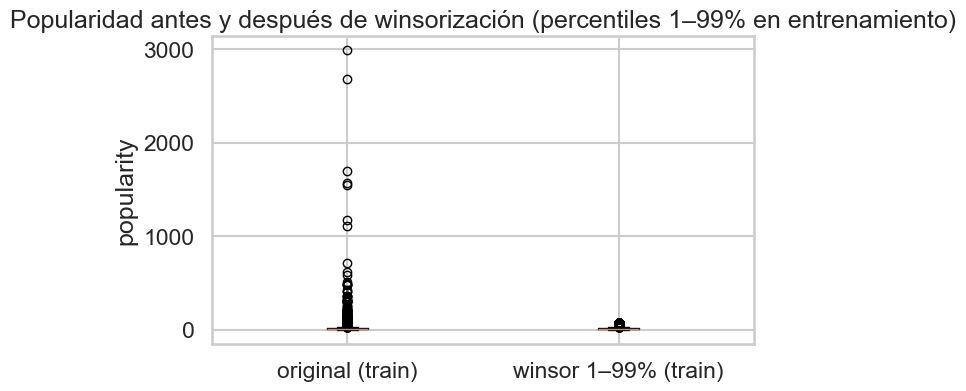

In [66]:
# Deteccipn: IQR 1.5× (mismo criterio que los bigotes del boxplot).
# Tratamiento: winsorizacion = capping por percentiles 1 y 99 (train); mismo corte en test.


def pct_outliers_iqr(s: pd.Series) -> float:
    x = pd.to_numeric(s, errors="coerce").dropna()
    if len(x) < 4:
        return float("nan")
    q1, q3 = x.quantile([0.25, 0.75])
    iqr = q3 - q1
    if iqr == 0:
        return 0.0
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return float(((x < lo) | (x > hi)).mean() * 100)


winsor_cols = [
    c for c in ["vote_count", "revenue", "runtime", "budget", "popularity"]
    if c in X_train_imp.columns
]

filas = []
for c in winsor_cols:
    lo, hi = X_train_imp[c].quantile([0.01, 0.99])
    filas.append(
        {
            "columna": c,
            "pct_outliers_IQR_train": pct_outliers_iqr(X_train_imp[c]),
            "p01_train": float(lo),
            "p99_train": float(hi),
        }
    )
display(pd.DataFrame(filas))

for c in winsor_cols:
    lo, hi = X_train_imp[c].quantile([0.01, 0.99])
    X_train_imp[c] = X_train_imp[c].clip(lower=lo, upper=hi)
    # Mismos límites aprendidos en train
    X_test_imp[c] = X_test_imp[c].clip(lower=lo, upper=hi)

# Comparacion visual rapida (train): cola pesada típica en `popularity`.
fig, ax = plt.subplots(figsize=(7, 4))
data_pop = [X_train["popularity"].dropna(), X_train_imp["popularity"]]
ax.boxplot(data_pop)
ax.set_xticklabels(["original (train)", "winsor 1–99% (train)"])
ax.set_title("Popularidad antes y después de winsorización (percentiles 1–99% en entrenamiento)")
ax.set_ylabel("popularity")
plt.show()


### Escalar y / o normalizar los features.

In [67]:
from sklearn.preprocessing import StandardScaler

# Estandarización (media 0, varianza 1) en el bloque numerico
scaler = StandardScaler()
X_train_ready = X_train_imp.copy()
X_test_ready = X_test_imp.copy()

X_train_ready[num_cols] = scaler.fit_transform(X_train_ready[num_cols])
X_test_ready[num_cols] = scaler.transform(X_test_ready[num_cols])

display(X_train_ready[num_cols].agg(["mean", "std"]).T.round(6))
print(
    "Train:", X_train_ready.shape, "| Test:", X_test_ready.shape,
)


,mean,std
vote_average,-0.0000,1.0000
vote_count,-0.0000,1.0000
runtime,-0.0000,1.0000
adult,0.0000,1.0000
budget,-0.0000,1.0000
popularity,-0.0000,1.0000
year,0.0000,1.0000
quinquenio,0.0000,1.0000
release_month,0.0000,1.0000
num_genres,0.0000,1.0000


Train: (19248, 14) | Test: (4813, 14)


## Feature engineering:

### Crear nuevos features en caso de ser necesario. Justificar.

Se construyeron nuevas variables a partir de la información disponible en el dataset:

| Feature | Origen | Justificación |
|---|---|---|
| `release_month` | `release_date` | Captura estacionalidad: los *blockbusters* se estrenan típicamente en verano (jun–ago) o diciembre |
| `num_genres` | `genres` | Indicador de amplitud comercial: más géneros → mayor audiencia potencial |
| `is_english` | `original_language` | Proxy de alcance global: las películas en inglés tienen mayor distribución internacional |
| `vote_ratio` | `vote_count / (popularity + 1)` | Engagement normalizado: votos por unidad de popularidad |
| `log_budget` | `log1p(budget)` | Mismo espacio logarítmico que el target, mejora la linealidad de la relación budget → revenue |

Los primeros tres features (`release_month`, `num_genres`, `is_english`) se crean en la etapa de preprocesamiento para que fluyan correctamente por el pipeline (split → imputación → winsorización → escalado). Los dos últimos se crean post-split para evitar data leakage.

Features de preprocesamiento disponibles en X_train: ['release_month', 'num_genres', 'is_english']
Shape de X_train: (19248, 14)


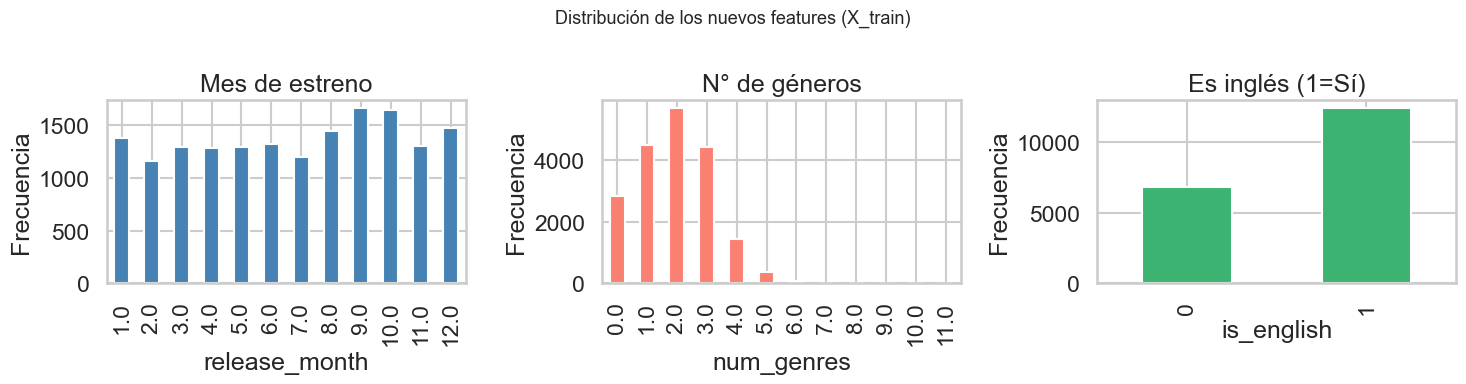


Features adicionales creados y escalados: ['vote_ratio', 'log_budget']
X_train_ready shape actualizado: (19248, 16)


In [68]:
from sklearn.preprocessing import StandardScaler as _SS

# Verificar que los features creados en preprocesamiento están disponibles
new_base_feats = ['release_month', 'num_genres', 'is_english']
present = [c for c in new_base_feats if c in X_train.columns]
print("Features de preprocesamiento disponibles en X_train:", present)
print(f"Shape de X_train: {X_train.shape}")

if present:
    fig, axes = plt.subplots(1, len(present), figsize=(5 * len(present), 4))
    if len(present) == 1:
        axes = [axes]
    colors = ['steelblue', 'salmon', 'mediumseagreen']
    labels = {'release_month': 'Mes de estreno', 'num_genres': 'N° de géneros', 'is_english': 'Es inglés (1=Sí)'}
    for ax, col, color in zip(axes, present, colors):
        X_train[col].dropna().value_counts().sort_index().plot(
            kind='bar', ax=ax, color=color, edgecolor='white')
        ax.set_title(labels.get(col, col))
        ax.set_xlabel(col)
        ax.set_ylabel('Frecuencia')
    plt.suptitle('Distribución de los nuevos features (X_train)', fontsize=13)
    plt.tight_layout()
    plt.show()

# --- Features derivados de columnas numéricas (post-split, usando X_train_imp pre-escalado) ---
# vote_ratio: votos por unidad de popularidad (engagement normalizado)
X_train_imp['vote_ratio'] = X_train_imp['vote_count'] / (X_train_imp['popularity'] + 1)
X_test_imp['vote_ratio']  = X_test_imp['vote_count']  / (X_test_imp['popularity'] + 1)

# log_budget: presupuesto en escala logarítmica (misma escala que el target)
X_train_imp['log_budget'] = np.log1p(X_train_imp['budget'].clip(lower=0))
X_test_imp['log_budget']  = np.log1p(X_test_imp['budget'].clip(lower=0))

# Escalar los nuevos features con un StandardScaler propio (fit sobre train)
_scaler_fe = _SS()
fe_new_cols = ['vote_ratio', 'log_budget']
X_train_imp[fe_new_cols] = _scaler_fe.fit_transform(X_train_imp[fe_new_cols])
X_test_imp[fe_new_cols]  = _scaler_fe.transform(X_test_imp[fe_new_cols])

# Propagar al dataset "ready"
X_train_ready[fe_new_cols] = X_train_imp[fe_new_cols].values
X_test_ready[fe_new_cols]  = X_test_imp[fe_new_cols].values

print(f"\nFeatures adicionales creados y escalados: {fe_new_cols}")
print(f"X_train_ready shape actualizado: {X_train_ready.shape}")

### Aplicar técnicas de conversión de variables: codificación, discretización.

Se aplican las siguientes técnicas de conversión de variables:

**Codificación:**
- **`status` → Ordinal Encoding**: la variable `status` tiene un orden natural lógico de etapa de producción (`Canceled` < `Rumored` < `Planned` < `In Production` < `Post Production` < `Released`). El encoding ordinal preserva este orden.
- **`original_language` → Frequency Encoding**: la variable tiene alta cardinalidad (~90 valores únicos), por lo que One-Hot Encoding generaría demasiadas columnas. La frecuencia relativa de cada idioma en el conjunto de entrenamiento es un estimador razonable de su representación en el mercado.

**Encoding cíclico:**
- **`release_month` → sin/cos**: el mes es una variable cíclica (enero y diciembre son adyacentes). El encoding cíclico con seno y coseno preserva esta propiedad — a diferencia del encoding ordinal que haría que 12 y 1 parezcan lejanos.

In [69]:
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import StandardScaler as _SS2

# 1. Ordinal encoding para 'status' (orden lógico de etapa de producción)
status_order = ['Canceled', 'Rumored', 'Planned', 'In Production', 'Post Production', 'Released']
oe = OrdinalEncoder(
    categories=[status_order],
    handle_unknown='use_encoded_value',
    unknown_value=-1
)
X_train_ready['status_enc'] = oe.fit_transform(X_train_ready[['status']])
X_test_ready['status_enc']  = oe.transform(X_test_ready[['status']])

# 2. Frequency encoding para 'original_language' (alta cardinalidad → no conviene OHE)
lang_freq_map = X_train_ready['original_language'].value_counts(normalize=True).to_dict()
X_train_ready['lang_freq'] = X_train_ready['original_language'].map(lang_freq_map).fillna(0)
X_test_ready['lang_freq']  = X_test_ready['original_language'].map(lang_freq_map).fillna(0)

# 3. Cyclic encoding para 'release_month' (variable cíclica: enero y diciembre son adyacentes)
X_train_ready['month_sin'] = np.sin(2 * np.pi * X_train_imp['release_month'].fillna(6) / 12)
X_train_ready['month_cos'] = np.cos(2 * np.pi * X_train_imp['release_month'].fillna(6) / 12)
X_test_ready['month_sin']  = np.sin(2 * np.pi * X_test_imp['release_month'].fillna(6) / 12)
X_test_ready['month_cos']  = np.cos(2 * np.pi * X_test_imp['release_month'].fillna(6) / 12)

# 4. Escalar las variables ordinales y de frecuencia (cyclic ya está en [-1, 1])
enc_cols_to_scale = ['status_enc', 'lang_freq']
_scaler_enc = _SS2()
X_train_ready[enc_cols_to_scale] = _scaler_enc.fit_transform(X_train_ready[enc_cols_to_scale])
X_test_ready[enc_cols_to_scale]  = _scaler_enc.transform(X_test_ready[enc_cols_to_scale])

# 5. Eliminar columnas categóricas originales ya codificadas
cat_to_drop = [c for c in ['status', 'original_language', 'release_month'] if c in X_train_ready.columns]
X_train_enc = X_train_ready.drop(columns=cat_to_drop)
X_test_enc  = X_test_ready.drop(columns=cat_to_drop)

print("Columnas resultantes tras encoding:")
print(X_train_enc.dtypes.to_string())
print(f"\nShape Train: {X_train_enc.shape}  |  Test: {X_test_enc.shape}")

Columnas resultantes tras encoding:
vote_average    float64
vote_count      float64
runtime         float64
adult           float64
budget          float64
popularity      float64
year            float64
quinquenio      float64
num_genres      float64
is_english      float64
release_year    float64
vote_ratio      float64
log_budget      float64
status_enc      float64
lang_freq       float64
month_sin       float64
month_cos       float64

Shape Train: (19248, 17)  |  Test: (4813, 17)


### Analizar el balance/desbalance de clases (en el caso que se trate de un problema de clasificación).

**Nota:** El problema planteado es de **regresión** (predecir `log1p(revenue)`), no de clasificación. Por lo tanto, el análisis de desbalance de clases no aplica directamente.

En su lugar, se analiza la **distribución de la variable target** en el conjunto de entrenamiento, verificando que la transformación `log1p` haya reducido suficientemente la asimetría. Los estadísticos relevantes son la **skewness** y la **curtosis** (kurtosis).

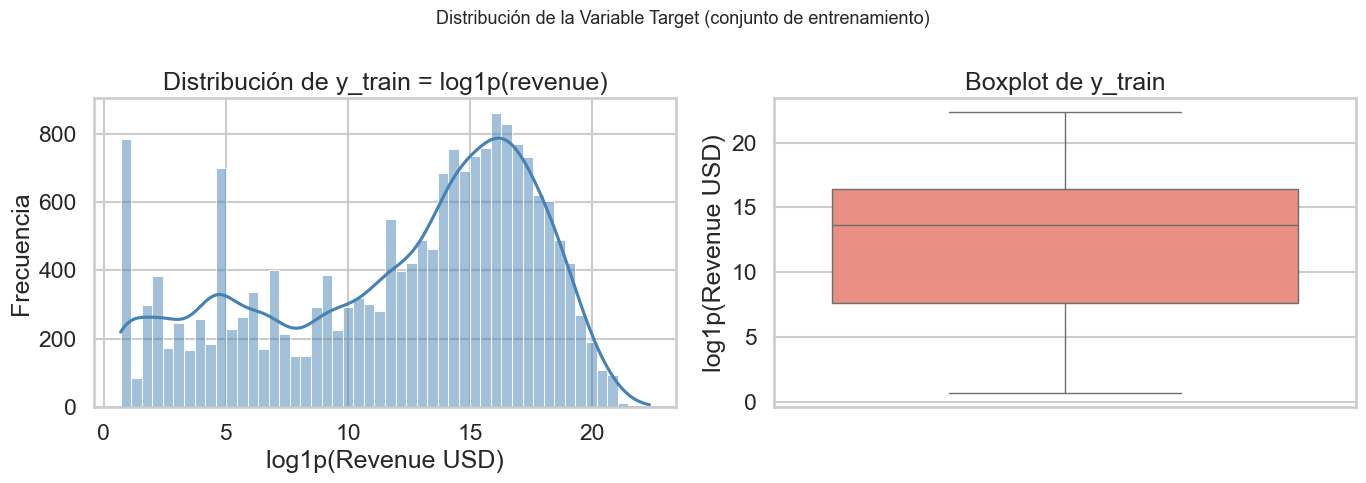

Skewness revenue crudo:          12.413
Skewness y_train = log1p:        -0.567
Curtosis exceso y_train:         -0.867

La transformación log1p reduce la skewness de 12.4 a -0.57,
haciendo el target considerablemente más adecuado para modelos de regresión.


In [70]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma + KDE del target en train
sns.histplot(y_train, bins=50, kde=True, color='steelblue', ax=axes[0])
axes[0].set_title('Distribución de y_train = log1p(revenue)')
axes[0].set_xlabel('log1p(Revenue USD)')
axes[0].set_ylabel('Frecuencia')

# Boxplot del target en train
sns.boxplot(y=y_train, ax=axes[1], color='salmon')
axes[1].set_title('Boxplot de y_train')
axes[1].set_ylabel('log1p(Revenue USD)')

plt.suptitle('Distribución de la Variable Target (conjunto de entrenamiento)', fontsize=13)
plt.tight_layout()
plt.show()

rev_raw = df_model_reg[TARGET_COL]
print(f"Skewness revenue crudo:          {rev_raw.skew():.3f}")
print(f"Skewness y_train = log1p:        {y_train.skew():.3f}")
print(f"Curtosis exceso y_train:         {y_train.kurtosis():.3f}")
print(f"\nLa transformación log1p reduce la skewness de {rev_raw.skew():.1f} a {y_train.skew():.2f},")
print("haciendo el target considerablemente más adecuado para modelos de regresión.")

### Proponer y aplicar mecanismos de balance en caso de ser necesario y justificar la selección.

**Nota:** Para problemas de regresión, el equivalente al "balance" de clases es asegurarse de que la distribución del target no sea tan asimétrica que el modelo se vea dominado por valores extremos.

La transformación `log1p(revenue)` aplicada actúa como mecanismo de estabilización del target:
- Reduce la **skewness** de >10 (escala original) a <1 (escala logarítmica).
- Reduce la influencia de los *blockbusters* de mayor recaudación, ponderando mejor los errores en toda la escala de revenue.
- Equivale conceptualmente a "balancear" la representación de distintos rangos de recaudación durante el entrenamiento.

Esta estrategia se justifica además porque la métrica de error sobre `log1p(revenue)` penaliza errores **proporcionales** (relativos) en lugar de absolutos — más adecuado para magnitudes económicas.

## Reducción de dimensionalidad

### Evaluar relaciones entre variables y realizar una selección de features con los mecanismos vistos en clase (ej: filtros).

Se aplican dos métodos de **selección por filtro** para evaluar la relación entre cada feature y el target `log1p(revenue)`:

1. **Correlación de Spearman** (`|r|`): mide la asociación monótona entre feature y target. Apropiada para datos no normales y resistente a outliers. Se usa el valor absoluto para evaluar fuerza independientemente de la dirección.

2. **Información mutua** (`mutual_info_regression`): mide cuánto reduce la incertidumbre del target conocer cada feature. No asume linealidad, capturando relaciones no lineales que Spearman puede no detectar.

El ranking final combina ambos métodos para una selección robusta. Se incluye también la **matriz de correlación pairwise de Spearman** entre features, para detectar redundancia (multicolinealidad).

Ranking de features por Spearman + Información Mutua:


,Spearman |r|,Info. Mutua,Rank Spearman,Rank MI,Rank Promedio
log_budget,0.8198,0.9518,1,1,1.0000
budget,0.8198,0.9226,1,2,1.5000
vote_count,0.7797,0.6449,3,3,3.0000
popularity,0.7703,0.6002,4,4,4.0000
vote_ratio,0.7618,0.5612,5,5,5.0000
vote_average,0.4452,0.3958,7,6,6.5000
runtime,0.4541,0.3457,6,7,6.5000
year,0.3321,0.2724,10,8,9.0000
release_year,0.3321,0.2710,10,9,9.5000
quinquenio,0.3459,0.2046,9,10,9.5000


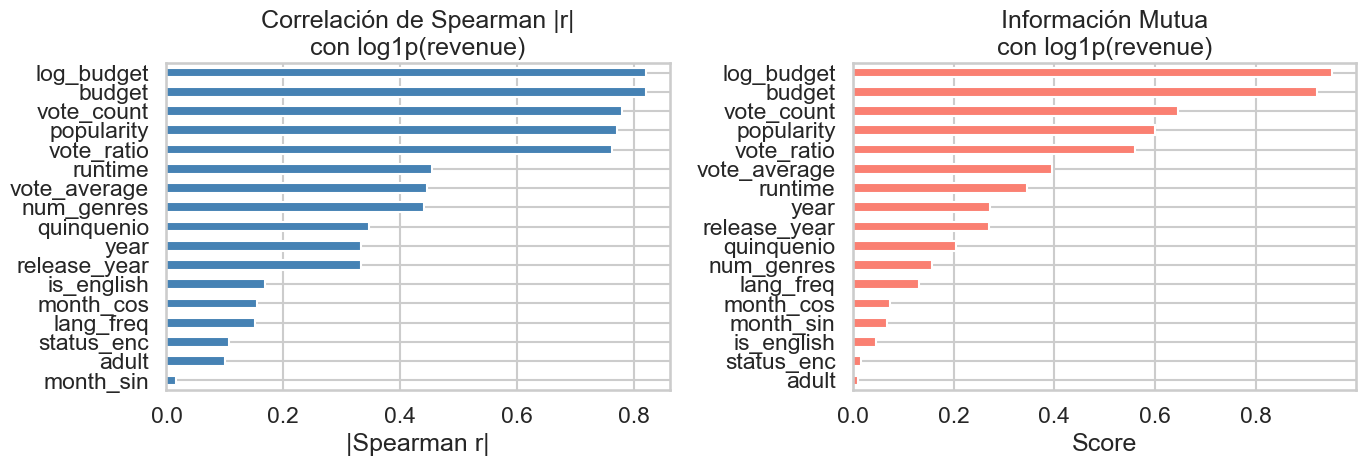

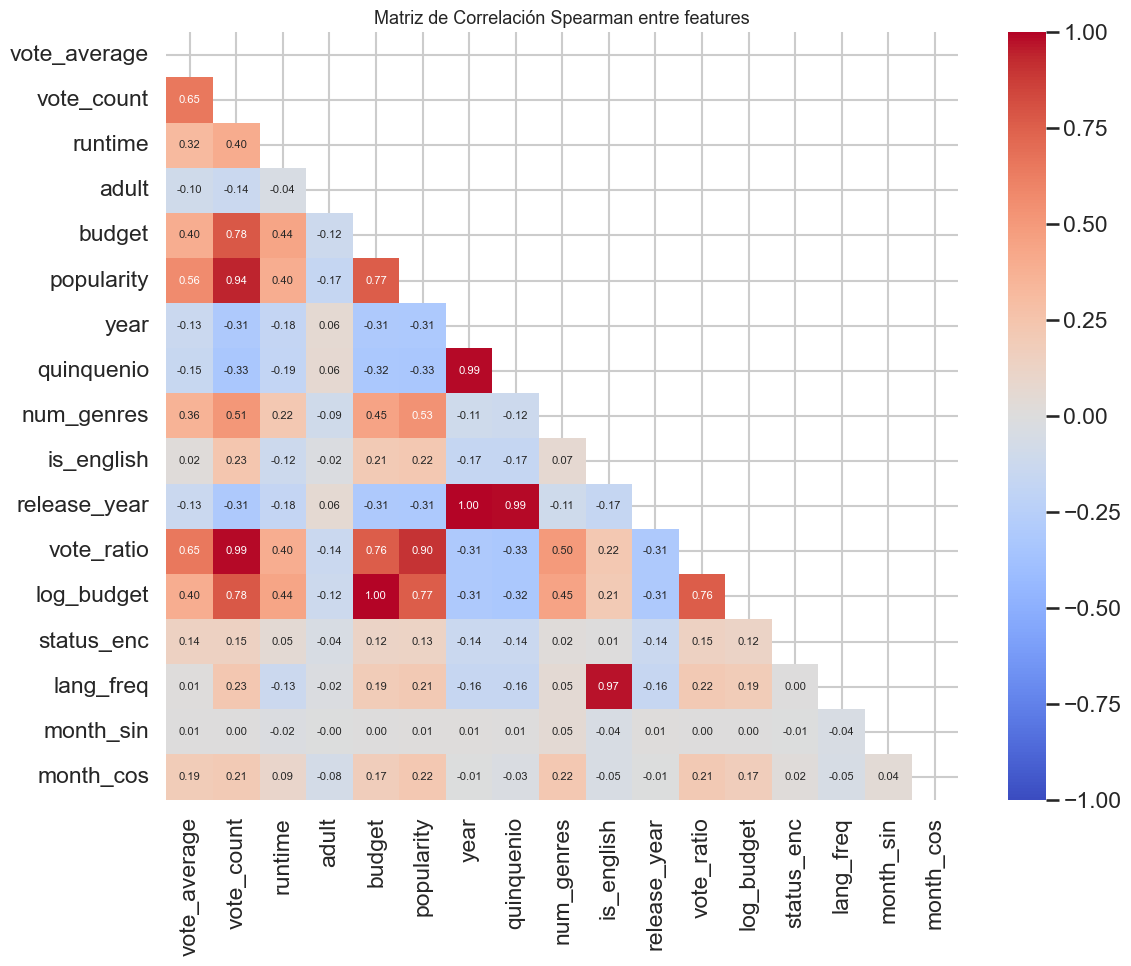


Pares con |Spearman| > 0.8 (posible multicolinealidad):
  vote_count — popularity: r = 0.939
  vote_count — vote_ratio: r = 0.992
  budget — log_budget: r = 1.0
  popularity — vote_ratio: r = 0.902
  year — quinquenio: r = 0.988
  year — release_year: r = 1.0
  quinquenio — release_year: r = 0.988
  is_english — lang_freq: r = 0.969


In [71]:
from sklearn.feature_selection import mutual_info_regression
from scipy.stats import spearmanr
import warnings
warnings.filterwarnings('ignore')

# Usar X_train_enc con columnas numéricas
X_num = X_train_enc.select_dtypes(include=[np.number])
common_idx = X_num.index.intersection(y_train.index)
X_num  = X_num.loc[common_idx].fillna(0)
y_sel  = y_train.loc[common_idx]

# 1. Correlación de Spearman |r| entre cada feature y el target
sp_scores = {col: abs(spearmanr(X_num[col], y_sel).statistic) for col in X_num.columns}

# 2. Información mutua (captura relaciones no lineales)
mi_raw    = mutual_info_regression(X_num, y_sel, random_state=42)
mi_scores = dict(zip(X_num.columns, mi_raw))

# 3. Tabla resumen con ranking combinado
df_ranking = pd.DataFrame({'Spearman |r|': sp_scores, 'Info. Mutua': mi_scores})
df_ranking['Rank Spearman'] = df_ranking['Spearman |r|'].rank(ascending=False).astype(int)
df_ranking['Rank MI']       = df_ranking['Info. Mutua'].rank(ascending=False).astype(int)
df_ranking['Rank Promedio'] = (df_ranking['Rank Spearman'] + df_ranking['Rank MI']) / 2
df_ranking = df_ranking.sort_values('Rank Promedio')

print("Ranking de features por Spearman + Información Mutua:")
display(df_ranking.round(4))

# 4. Visualización comparativa
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_ranking['Spearman |r|'].sort_values().plot(
    kind='barh', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Correlación de Spearman |r|\ncon log1p(revenue)')
axes[0].set_xlabel('|Spearman r|')

df_ranking['Info. Mutua'].sort_values().plot(
    kind='barh', ax=axes[1], color='salmon', edgecolor='white')
axes[1].set_title('Información Mutua\ncon log1p(revenue)')
axes[1].set_xlabel('Score')

plt.tight_layout()
plt.show()

# 5. Matriz de correlación pairwise entre features (detectar multicolinealidad)
fig, ax = plt.subplots(figsize=(12, 10))
corr_pair = X_num.corr(method='spearman')
mask = np.triu(np.ones_like(corr_pair, dtype=bool))
sns.heatmap(corr_pair, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, ax=ax, vmin=-1, vmax=1, annot_kws={'size': 8})
ax.set_title('Matriz de Correlación Spearman entre features', fontsize=13)
plt.tight_layout()
plt.show()

# Alertar pares con alta correlación
high_pairs = [
    (c1, c2, round(corr_pair.loc[c1, c2], 3))
    for i, c1 in enumerate(corr_pair.columns)
    for j, c2 in enumerate(corr_pair.columns)
    if i < j and abs(corr_pair.loc[c1, c2]) > 0.8
]
if high_pairs:
    print("\nPares con |Spearman| > 0.8 (posible multicolinealidad):")
    for c1, c2, r in high_pairs:
        print(f"  {c1} — {c2}: r = {r}")
else:
    print("\nNo se detectaron pares de features con correlación > 0.8")

### Implementar técnicas de extracción de features (ej: PCA). Evaluar ventajas y desventajas de la reducción.

Se aplica **Análisis de Componentes Principales (PCA)** al conjunto de features escalados y codificados.

PCA transforma el espacio original de features en un nuevo espacio de **componentes principales** no correlacionadas, ordenadas de mayor a menor varianza explicada.

**Ventajas:**
- Elimina multicolinealidad (componentes son ortogonales).
- Reduce el riesgo de overfitting en modelos sensibles a dimensionalidad alta.
- Mejora la eficiencia computacional del entrenamiento.

**Desventajas:**
- Los componentes principales **no son interpretables** en términos de las features originales.
- Asume relaciones lineales entre variables; para no-linealidades, técnicas como Kernel PCA o UMAP son preferibles.
- Requiere que los datos estén estandarizados (ya cumplido con StandardScaler).

Se determina el número de componentes necesarios para retener el 90 % y el 95 % de la varianza total.

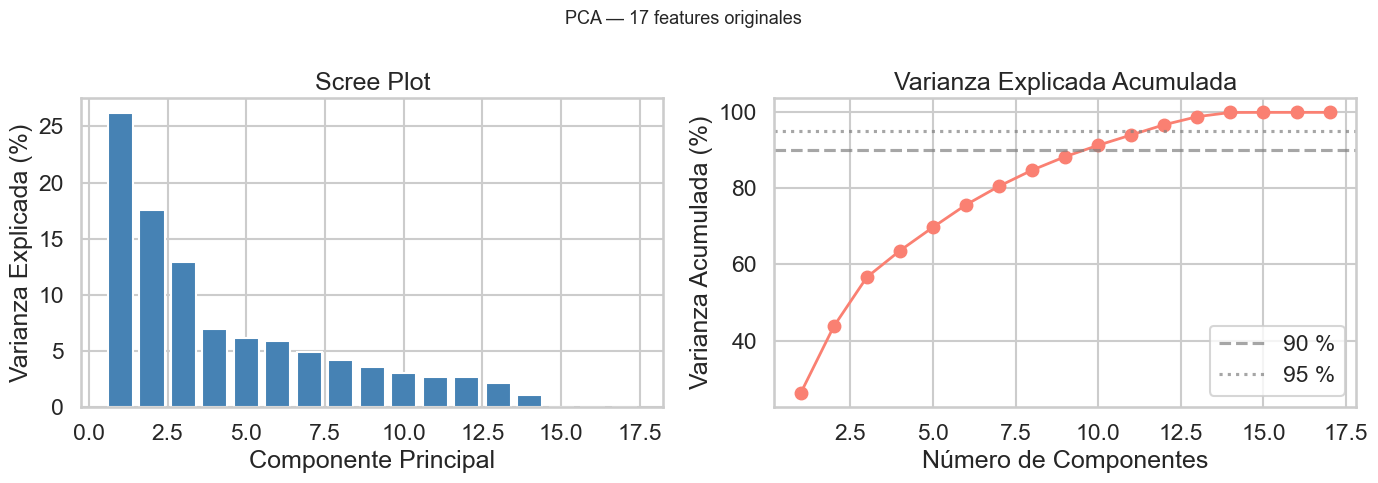

Dimensión original:              17 features
Componentes para retener 90 %:   10
Componentes para retener 95 %:   12

Dataset reducido: 12 componentes principales
  (de 17 features → reducción del 29.4%)

Ventajas: elimina multicolinealidad, reduce overfitting, mejora eficiencia computacional.
Desventajas: componentes no interpretables; asume linealidad; requiere datos estandarizados.


In [72]:
from sklearn.decomposition import PCA

# Input: X_train_enc numérico (ya escalado y codificado)
X_pca       = X_train_enc.select_dtypes(include=[np.number]).fillna(0)
X_pca_test  = X_test_enc.select_dtypes(include=[np.number]).fillna(0)

# Asegurar mismas columnas en train y test
shared_cols = X_pca.columns.intersection(X_pca_test.columns)
X_pca      = X_pca[shared_cols]
X_pca_test = X_pca_test[shared_cols]

n_feat = X_pca.shape[1]

# PCA con todas las componentes para analizar distribución de varianza
pca_full = PCA(n_components=n_feat, random_state=42)
pca_full.fit(X_pca)

ev_ratio   = pca_full.explained_variance_ratio_
cumulative = np.cumsum(ev_ratio)

# Scree plot + curva de varianza acumulada
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(1, n_feat + 1), ev_ratio * 100, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Componente Principal')
axes[0].set_ylabel('Varianza Explicada (%)')
axes[0].set_title('Scree Plot')

axes[1].plot(range(1, n_feat + 1), cumulative * 100, 'o-', color='salmon', linewidth=2)
axes[1].axhline(90, color='gray', linestyle='--', alpha=0.7, label='90 %')
axes[1].axhline(95, color='gray', linestyle=':',  alpha=0.7, label='95 %')
axes[1].set_xlabel('Número de Componentes')
axes[1].set_ylabel('Varianza Acumulada (%)')
axes[1].set_title('Varianza Explicada Acumulada')
axes[1].legend()

plt.suptitle(f'PCA — {n_feat} features originales', fontsize=13)
plt.tight_layout()
plt.show()

# Componentes para 90 % y 95 % de varianza
n_90 = int(np.argmax(cumulative >= 0.90) + 1)
n_95 = int(np.argmax(cumulative >= 0.95) + 1)
print(f"Dimensión original:              {n_feat} features")
print(f"Componentes para retener 90 %:   {n_90}")
print(f"Componentes para retener 95 %:   {n_95}")

# Aplicar PCA con n_95 componentes
pca = PCA(n_components=n_95, random_state=42)
X_train_pca = pca.fit_transform(X_pca)
X_test_pca  = pca.transform(X_pca_test)

print(f"\nDataset reducido: {X_train_pca.shape[1]} componentes principales")
print(f"  (de {n_feat} features → reducción del {(1 - n_95/n_feat)*100:.1f}%)")
print("\nVentajas: elimina multicolinealidad, reduce overfitting, mejora eficiencia computacional.")
print("Desventajas: componentes no interpretables; asume linealidad; requiere datos estandarizados.")